# Notebook - Find best Drug compound for Staphylococcus aureus bacteria

In this notebook, we demonstrate the use of MACAW embeddings to model binding affinity to a protein receptor of pharmacological interest. MACAW embeddings are then applied to identify promising candidate molecules in a custom virtual library.

In [37]:
import sys
import os

# Completely suppress stderr output
sys.stderr = open(os.devnull, 'w')

# Now import everything
import warnings
warnings.filterwarnings('ignore')

In [38]:
import os
import csv
import numpy as np
import pandas as pd


from sklearn.model_selection import KFold, GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import r2_score

#Needed to show molecules
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole 
import seaborn as sns
from joblib import load

import sys
sys.path.append('../')

import macaw
print(macaw.__version__)
from macaw import *

import warnings
warnings.filterwarnings("ignore")

import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams['font.family'] = 'DejaVu Sans'
matplotlib.rcParams['font.sans-serif'] = ['DejaVu Sans']
matplotlib.rcParams['figure.dpi'] = 96
matplotlib.rcParams['savefig.dpi'] = 600

%run "./plotting.py"

1.0.1


In [39]:
%config InlineBackend.figure_format = 'retina'

## 1. Regression Target: pPotency

### 1.1 Data preparation

In [40]:
dataDir = '/mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/'
modelBuildingDataDir = os.path.join(dataDir, 'modelBuildingData/')
resultsDir = os.path.join(dataDir, 'Results/')

In [41]:
allBacteriaData_chEMBL_wMACAW = pd.read_csv(modelBuildingDataDir + 'allBacteriaData_chEMBL_uM_wMACAW.csv')

In [42]:
allBacteriaData_chEMBL_wMACAW

,Unnamed: 0,molecule_chembl_id,smiles,molecular_formula,inchi_key,inchi,molecular_weight,type,standard_value,standard_units,...,macaw_5,macaw_6,macaw_7,macaw_8,macaw_9,macaw_10,macaw_11,macaw_12,macaw_13,macaw_14
0,1,CHEMBL8,O=C(O)c1cn(C2CC2)c2cc(N3CCNCC3)c(F)cc2c1=O,C17H18FN3O3,MYSWGUAQZAJSOK-UHFFFAOYSA-N,InChI=1S/C17H18FN3O3/c18-13-7-11-14(8-15(13)20...,331.35,Small molecule,0.25,ug.mL-1,...,-0.030681,-0.127148,-0.133923,-0.111388,0.084428,0.026623,0.160258,0.116619,-0.014980,0.063359
1,2,CHEMBL606360,COc1ccc(C(=O)/C=C/c2cn(-c3ccccc3)nc2-c2ccc(Cl)...,C26H21ClN2O3,KEINEPLOMWOUNE-XNTDXEJSSA-N,InChI=1S/C26H21ClN2O3/c1-31-22-13-14-23(25(16-...,444.92,Small molecule,100.00,ug.mL-1,...,-0.092330,0.011442,-0.113492,0.153756,0.124025,-0.051814,0.022991,0.030415,-0.106818,0.018152
2,3,CHEMBL4089761,NC[C@H]1O[C@H](O[C@H]2[C@H](O)[C@@H](O[C@H]3O[...,C40H59FN10O14,VETOBWPFYDUOPP-FFKZLMLRSA-N,InChI=1S/C40H59FN10O14/c41-21-9-19-24(51(18-1-...,922.97,Small molecule,1.50,ug.mL-1,...,-0.127232,-0.126869,-0.091832,0.029565,0.068529,-0.010103,0.059577,0.082352,-0.124721,0.093080
3,4,CHEMBL1241817,O=C(Cn1ncc2cc([N+](=O)[O-])ccc21)N/N=C/c1cccc(...,C16H12N6O5,DGJBCVGFPFQIOC-CAOOACKPSA-N,InChI=1S/C16H12N6O5/c23-16(19-17-8-11-2-1-3-13...,368.31,Small molecule,16.00,ug.mL-1,...,0.123449,-0.019707,0.055608,0.003291,0.046833,0.041516,-0.002765,-0.004522,-0.037508,0.021961
4,5,CHEMBL1242158,O=C(Cn1ncc2cc([N+](=O)[O-])ccc21)NN1C(=O)CSC1c...,C18H14ClN5O4S,SJWDBKWBFHCWPA-UHFFFAOYSA-N,InChI=1S/C18H14ClN5O4S/c19-13-3-1-11(2-4-13)18...,431.86,Small molecule,16.00,ug.mL-1,...,0.039788,-0.006643,0.058043,0.085609,-0.011400,-0.017518,0.076169,0.022291,-0.003597,-0.032543
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
162373,309581,CHEMBL4786844,CC(C)C[C@H](NC(=O)[C@H](CCCNC(=N)N)NC(=O)[C@H]...,C83H132N34O19,YJJSQMDJLSCZBG-OWVMLFFHSA-N,InChI=1S/C83H132N34O19/c1-42(2)29-57(75(132)10...,1910.19,Unknown,33500.00,nM,...,0.067898,0.020046,0.044115,-0.109868,-0.055894,0.110857,-0.255286,0.044038,-0.069828,-0.119326
162374,309582,CHEMBL4786844,CC(C)C[C@H](NC(=O)[C@H](CCCNC(=N)N)NC(=O)[C@H]...,C83H132N34O19,YJJSQMDJLSCZBG-OWVMLFFHSA-N,InChI=1S/C83H132N34O19/c1-42(2)29-57(75(132)10...,1910.19,Unknown,67010.00,nM,...,0.067898,0.020046,0.044115,-0.109868,-0.055894,0.110857,-0.255286,0.044038,-0.069828,-0.119326
162375,309595,CHEMBL4557820,CC1(C)[C@@H](O[C@H]2OC[C@H](O)[C@H](O)[C@H]2O[...,C53H84O23,YEMXBZDJQOAHLA-KJIQPPNDSA-N,InChI=1S/C53H84O23/c1-48(2)29-9-12-52(6)30(8-7...,1089.23,Unknown,1148900.00,nM,...,0.034797,-0.073582,-0.181693,0.065255,0.069087,-0.058363,-0.012869,-0.083648,-0.090124,-0.091547
162376,309598,CHEMBL5171589,Clc1ccc2c(c1)C(NCCN1CCNCC1)=Nc1ccccc1O2,C19H21ClN4O,REXIYIBKBWXIKH-UHFFFAOYSA-N,InChI=1S/C19H21ClN4O/c20-14-5-6-17-15(13-14)19...,356.86,NaN,1510.00,nM,...,0.002278,0.035289,-0.055769,0.067635,-0.011393,-0.080972,0.108266,0.025874,0.174277,0.035933


### Filter columns

In [43]:
allBacteriaData_chEMBL_wMACAW = allBacteriaData_chEMBL_wMACAW.filter(
    items=["molecule_chembl_id", "smiles", "value_uM", "pPotency", "Virus"]
)
allBacteriaData_chEMBL_wMACAW

,molecule_chembl_id,smiles,value_uM,pPotency,Virus
0,CHEMBL8,O=C(O)c1cn(C2CC2)c2cc(N3CCNCC3)c(F)cc2c1=O,5.623413e+05,0.250000,Bacillus_subtilisData_chEMBL_combined.csv
1,CHEMBL606360,COc1ccc(C(=O)/C=C/c2cn(-c3ccccc3)nc2-c2ccc(Cl)...,1.000000e-94,100.000000,Bacillus_subtilisData_chEMBL_combined.csv
2,CHEMBL4089761,NC[C@H]1O[C@H](O[C@H]2[C@H](O)[C@@H](O[C@H]3O[...,3.162278e+04,1.500000,Bacillus_subtilisData_chEMBL_combined.csv
3,CHEMBL1241817,O=C(Cn1ncc2cc([N+](=O)[O-])ccc21)N/N=C/c1cccc(...,1.000000e-10,16.000000,Bacillus_subtilisData_chEMBL_combined.csv
4,CHEMBL1242158,O=C(Cn1ncc2cc([N+](=O)[O-])ccc21)NN1C(=O)CSC1c...,1.000000e-10,16.000000,Bacillus_subtilisData_chEMBL_combined.csv
...,...,...,...,...,...
162373,CHEMBL4786844,CC(C)C[C@H](NC(=O)[C@H](CCCNC(=N)N)NC(=O)[C@H]...,3.350000e+01,4.474955,Listeria_monocytogenesData_chEMBL_combined.csv
162374,CHEMBL4786844,CC(C)C[C@H](NC(=O)[C@H](CCCNC(=N)N)NC(=O)[C@H]...,6.701000e+01,4.173860,Listeria_monocytogenesData_chEMBL_combined.csv
162375,CHEMBL4557820,CC1(C)[C@@H](O[C@H]2OC[C@H](O)[C@H](O)[C@H]2O[...,1.148900e+03,2.939718,Listeria_monocytogenesData_chEMBL_combined.csv
162376,CHEMBL5171589,Clc1ccc2c(c1)C(NCCN1CCNCC1)=Nc1ccccc1O2,1.510000e+00,5.821023,Listeria_monocytogenesData_chEMBL_combined.csv


### Remove the trailing 'Data_chEMBL_combined.csv' from each entry in the 'Virus' column

In [44]:
allBacteriaData_chEMBL_wMACAW['Virus'] = allBacteriaData_chEMBL_wMACAW['Virus'].str.replace('Data_chEMBL_combined.csv', '', regex=False)
allBacteriaData_chEMBL_wMACAW.rename(columns={'Virus': 'Bacteria'}, inplace=True)
allBacteriaData_chEMBL_wMACAW

,molecule_chembl_id,smiles,value_uM,pPotency,Bacteria
0,CHEMBL8,O=C(O)c1cn(C2CC2)c2cc(N3CCNCC3)c(F)cc2c1=O,5.623413e+05,0.250000,Bacillus_subtilis
1,CHEMBL606360,COc1ccc(C(=O)/C=C/c2cn(-c3ccccc3)nc2-c2ccc(Cl)...,1.000000e-94,100.000000,Bacillus_subtilis
2,CHEMBL4089761,NC[C@H]1O[C@H](O[C@H]2[C@H](O)[C@@H](O[C@H]3O[...,3.162278e+04,1.500000,Bacillus_subtilis
3,CHEMBL1241817,O=C(Cn1ncc2cc([N+](=O)[O-])ccc21)N/N=C/c1cccc(...,1.000000e-10,16.000000,Bacillus_subtilis
4,CHEMBL1242158,O=C(Cn1ncc2cc([N+](=O)[O-])ccc21)NN1C(=O)CSC1c...,1.000000e-10,16.000000,Bacillus_subtilis
...,...,...,...,...,...
162373,CHEMBL4786844,CC(C)C[C@H](NC(=O)[C@H](CCCNC(=N)N)NC(=O)[C@H]...,3.350000e+01,4.474955,Listeria_monocytogenes
162374,CHEMBL4786844,CC(C)C[C@H](NC(=O)[C@H](CCCNC(=N)N)NC(=O)[C@H]...,6.701000e+01,4.173860,Listeria_monocytogenes
162375,CHEMBL4557820,CC1(C)[C@@H](O[C@H]2OC[C@H](O)[C@H](O)[C@H]2O[...,1.148900e+03,2.939718,Listeria_monocytogenes
162376,CHEMBL5171589,Clc1ccc2c(c1)C(NCCN1CCNCC1)=Nc1ccccc1O2,1.510000e+00,5.821023,Listeria_monocytogenes


### Keep only data for `Staphylococcus_aureus` bacteria

In [45]:
StaphylococcusBacteriaData_chEMBL_wMACAW = allBacteriaData_chEMBL_wMACAW[allBacteriaData_chEMBL_wMACAW['Bacteria'] == 'Staphylococcus_aureus']
StaphylococcusBacteriaData_chEMBL_wMACAW

,molecule_chembl_id,smiles,value_uM,pPotency,Bacteria
18773,CHEMBL1200628,CN[C@H](CC(C)C)C(=O)N[C@H]1C(=O)N[C@@H](CC(N)=...,1.659587e+05,0.780,Staphylococcus_aureus
18774,CHEMBL2164996,Cc1cc2c(cc1O)C1=C(C3=Cc4c(cc(O)c5cc(C)c(O)cc45...,1.000000e-19,25.000,Staphylococcus_aureus
18775,CHEMBL374478,CO[C@H]1/C=C/O[C@@]2(C)Oc3c(C)c(O)c4c(O)c(c(/C...,9.638290e+05,0.016,Staphylococcus_aureus
18776,CHEMBL376140,CN(C)c1cc(NC(=O)CNC(C)(C)C)c(O)c2c1C[C@H]1C[C@...,7.498942e+05,0.125,Staphylococcus_aureus
18777,CHEMBL376140,CN(C)c1cc(NC(=O)CNC(C)(C)C)c(O)c2c1C[C@H]1C[C@...,5.623413e+05,0.250,Staphylococcus_aureus
...,...,...,...,...,...
142570,CHEMBL5574512,CC(C)C[C@H](N)CN(CC(=O)N[C@@H](CCCCN)C(=O)N[C@...,1.000000e+02,4.000,Staphylococcus_aureus
142571,CHEMBL5570559,CC(C)C[C@H](NC(=O)[C@H](CC(C)C)NC(=O)[C@H](CCC...,1.000000e-26,32.000,Staphylococcus_aureus
142572,CHEMBL5570291,CC(C)C[C@H](NC(=O)[C@H](CC(C)C)NC(=O)[C@H](CCC...,1.000000e-26,32.000,Staphylococcus_aureus
142573,CHEMBL5574512,CC(C)C[C@H](N)CN(CC(=O)N[C@@H](CCCCN)C(=O)N[C@...,1.000000e-26,32.000,Staphylococcus_aureus


### Rename columns

In [46]:
StaphylococcusBacteriaData_chEMBL_wMACAW = StaphylococcusBacteriaData_chEMBL_wMACAW.rename(columns={
    "molecule_chembl_id": "compound_id",
    "smiles": "Smiles",
    "Bacteria" : "BacteriaClassifier",
})
StaphylococcusBacteriaData_chEMBL_wMACAW.head()

,compound_id,Smiles,value_uM,pPotency,BacteriaClassifier
18773,CHEMBL1200628,CN[C@H](CC(C)C)C(=O)N[C@H]1C(=O)N[C@@H](CC(N)=...,1.659587e+05,0.780,Staphylococcus_aureus
18774,CHEMBL2164996,Cc1cc2c(cc1O)C1=C(C3=Cc4c(cc(O)c5cc(C)c(O)cc45...,1.000000e-19,25.000,Staphylococcus_aureus
18775,CHEMBL374478,CO[C@H]1/C=C/O[C@@]2(C)Oc3c(C)c(O)c4c(O)c(c(/C...,9.638290e+05,0.016,Staphylococcus_aureus
18776,CHEMBL376140,CN(C)c1cc(NC(=O)CNC(C)(C)C)c(O)c2c1C[C@H]1C[C@...,7.498942e+05,0.125,Staphylococcus_aureus
18777,CHEMBL376140,CN(C)c1cc(NC(=O)CNC(C)(C)C)c(O)c2c1C[C@H]1C[C@...,5.623413e+05,0.250,Staphylococcus_aureus


### Compound Distribution Across Bacteriaes

In [47]:
Bacteria_counts = StaphylococcusBacteriaData_chEMBL_wMACAW['BacteriaClassifier'].value_counts().sort_values(ascending=False)
total_compounds = len(StaphylococcusBacteriaData_chEMBL_wMACAW)

print(f"\n{'Bacteria':<30} {'Count':>10} {'Percentage':>12}")
print("-"*70)

for Bacteria, count in Bacteria_counts.items():
    percentage = (count / total_compounds) * 100
    print(f"{Bacteria:<30} {count:>10} {percentage:>11.2f}%")

print("-"*70)
print(f"{'TOTAL':<30} {total_compounds:>10} {100.0:>11.2f}%")
print(f"\nNumber of unique Bacteriaes: {len(Bacteria_counts)}")


Bacteria                            Count   Percentage
----------------------------------------------------------------------
Staphylococcus_aureus              123802      100.00%
----------------------------------------------------------------------
TOTAL                              123802      100.00%

Number of unique Bacteriaes: 1


### Add `ID` column to left

In [48]:
StaphylococcusBacteriaData_chEMBL_wMACAW.insert(0, 'ID', range(1, len(StaphylococcusBacteriaData_chEMBL_wMACAW) + 1))
StaphylococcusBacteriaData_chEMBL_wMACAW.head()

,ID,compound_id,Smiles,value_uM,pPotency,BacteriaClassifier
18773,1,CHEMBL1200628,CN[C@H](CC(C)C)C(=O)N[C@H]1C(=O)N[C@@H](CC(N)=...,1.659587e+05,0.780,Staphylococcus_aureus
18774,2,CHEMBL2164996,Cc1cc2c(cc1O)C1=C(C3=Cc4c(cc(O)c5cc(C)c(O)cc45...,1.000000e-19,25.000,Staphylococcus_aureus
18775,3,CHEMBL374478,CO[C@H]1/C=C/O[C@@]2(C)Oc3c(C)c(O)c4c(O)c(c(/C...,9.638290e+05,0.016,Staphylococcus_aureus
18776,4,CHEMBL376140,CN(C)c1cc(NC(=O)CNC(C)(C)C)c(O)c2c1C[C@H]1C[C@...,7.498942e+05,0.125,Staphylococcus_aureus
18777,5,CHEMBL376140,CN(C)c1cc(NC(=O)CNC(C)(C)C)c(O)c2c1C[C@H]1C[C@...,5.623413e+05,0.250,Staphylococcus_aureus


### Add another filer to keep only these columns: `ID`, `compound_id`,	`Smiles`, `pPotency`, `BacteriaClassifier`

In [49]:
StaphylococcusBacteriaData_chEMBL_wMACAW = StaphylococcusBacteriaData_chEMBL_wMACAW.filter(
    items=["ID", "compound_id", "Smiles", "pPotency", "BacteriaClassifier"]
)
StaphylococcusBacteriaData_chEMBL_wMACAW.head()

,ID,compound_id,Smiles,pPotency,BacteriaClassifier
18773,1,CHEMBL1200628,CN[C@H](CC(C)C)C(=O)N[C@H]1C(=O)N[C@@H](CC(N)=...,0.780,Staphylococcus_aureus
18774,2,CHEMBL2164996,Cc1cc2c(cc1O)C1=C(C3=Cc4c(cc(O)c5cc(C)c(O)cc45...,25.000,Staphylococcus_aureus
18775,3,CHEMBL374478,CO[C@H]1/C=C/O[C@@]2(C)Oc3c(C)c(O)c4c(O)c(c(/C...,0.016,Staphylococcus_aureus
18776,4,CHEMBL376140,CN(C)c1cc(NC(=O)CNC(C)(C)C)c(O)c2c1C[C@H]1C[C@...,0.125,Staphylococcus_aureus
18777,5,CHEMBL376140,CN(C)c1cc(NC(=O)CNC(C)(C)C)c(O)c2c1C[C@H]1C[C@...,0.250,Staphylococcus_aureus


### Remove NaN, -ve and unphysical (>12) values in `pPotency` before cross-validation

| Range (pPotency) | IC₅₀/EC₅₀ (in M)          | Interpretation                                | Action              |
| ---------------- | -------------------- | --------------------------------------------- | ------------------- |
| **0–3**   | > 1×10⁻³ M (millimolar)     | Very weak or inactive compounds               | Drop         |
| **3–10**  | 1×10⁻³ – 1×10⁻¹⁰ M          | Normal drug-like activity range               | **Keep**                |
| **10–12** | 1×10⁻¹⁰ – 1×10⁻¹² M         | Extremely potent but still physically possible | **Keep (with caution)** |
| **>12**   | < 1×10⁻¹² M (picomolar–femto) | Physically unrealistic / likely data error     | Drop                |



In [50]:
print("Original shape:", StaphylococcusBacteriaData_chEMBL_wMACAW.shape)

StaphylococcusBacteriaData_chEMBL_wMACAW = StaphylococcusBacteriaData_chEMBL_wMACAW[StaphylococcusBacteriaData_chEMBL_wMACAW['pPotency'].notna() 
    & (StaphylococcusBacteriaData_chEMBL_wMACAW['pPotency'] > 0) & (StaphylococcusBacteriaData_chEMBL_wMACAW['pPotency'] < 12)]

print("Shape after cleaning 'pPotency' value:", StaphylococcusBacteriaData_chEMBL_wMACAW.shape)

Original shape: (123802, 5)
Shape after cleaning 'pPotency' value: (90807, 5)


### Remove duplicate compounds using Compute median potency per (Smiles, Bacteria) pair

In [51]:
duplicates = StaphylococcusBacteriaData_chEMBL_wMACAW.duplicated(subset=['Smiles', 'BacteriaClassifier'])
print("Remaining duplicates:", duplicates.sum())

Remaining duplicates: 57014


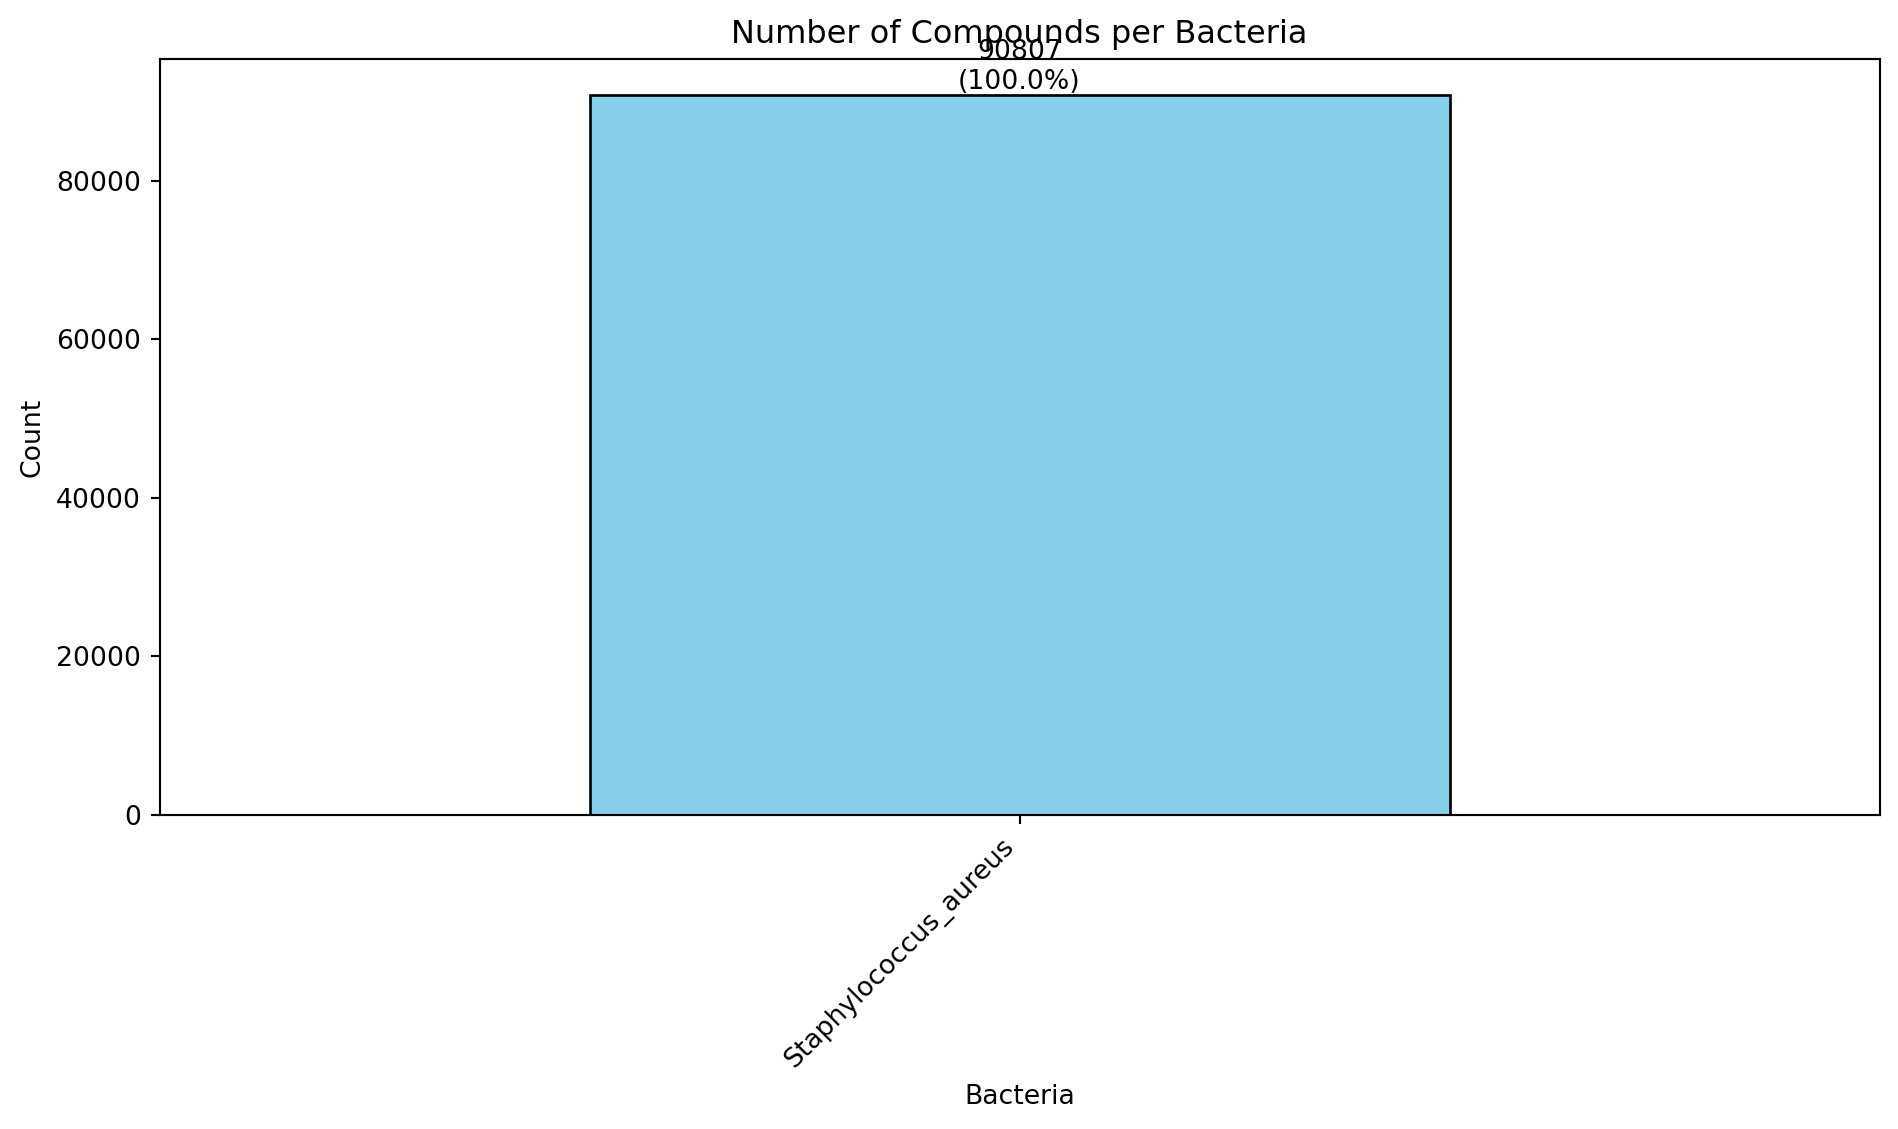

In [52]:
# Get counts and percentages
counts = StaphylococcusBacteriaData_chEMBL_wMACAW['BacteriaClassifier'].value_counts()
percentages = counts / counts.sum() * 100

# Create bar plot
plt.figure(figsize=(10, 6))
bars = counts.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Number of Compounds per Bacteria')
plt.xlabel('Bacteria')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')

# Annotate each bar with count and %
for i, (count, pct) in enumerate(zip(counts, percentages)):
    plt.text(
        i, count + 1,                 # position (x, y)
        f'{count}\n({pct:.1f}%)',     # label: count + percentage
        ha='center', va='bottom', fontsize=10
    )

plt.tight_layout()
plt.show()

In [53]:
StaphylococcusBacteriaData_chEMBL_wMACAW.to_csv(os.path.join(modelBuildingDataDir, "StaphylococcusBacteriaData_chEMBL_wMACAW_MLready.csv"), index=False)

### pPotency value distribution across each bacteria

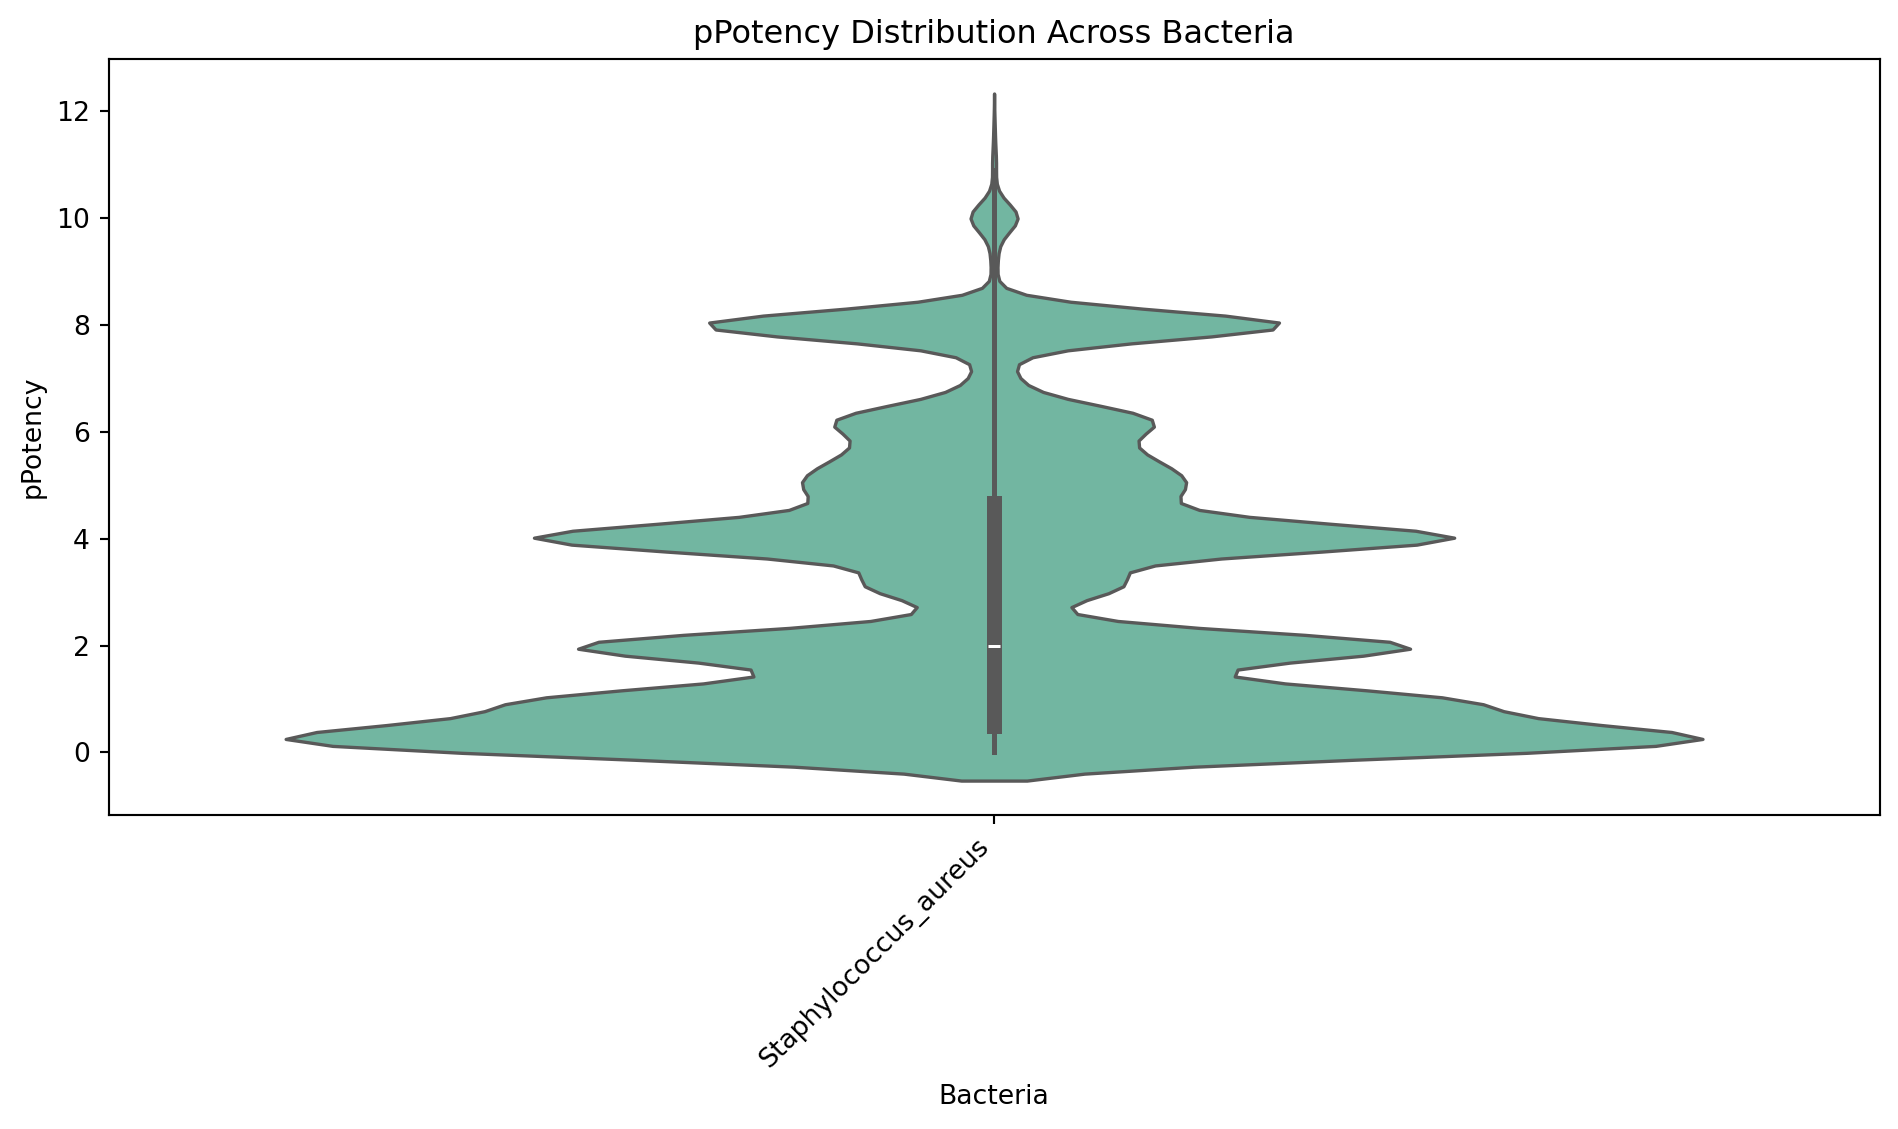

In [54]:
plt.figure(figsize=(10, 6))

sns.violinplot(
    data=StaphylococcusBacteriaData_chEMBL_wMACAW,
    x='BacteriaClassifier',
    y='pPotency',
    palette='Set2',
    inner='box'
)

plt.xticks(rotation=45, ha='right')
plt.title('pPotency Distribution Across Bacteria')
plt.xlabel('Bacteria')
plt.ylabel('pPotency')
plt.tight_layout()
plt.show()

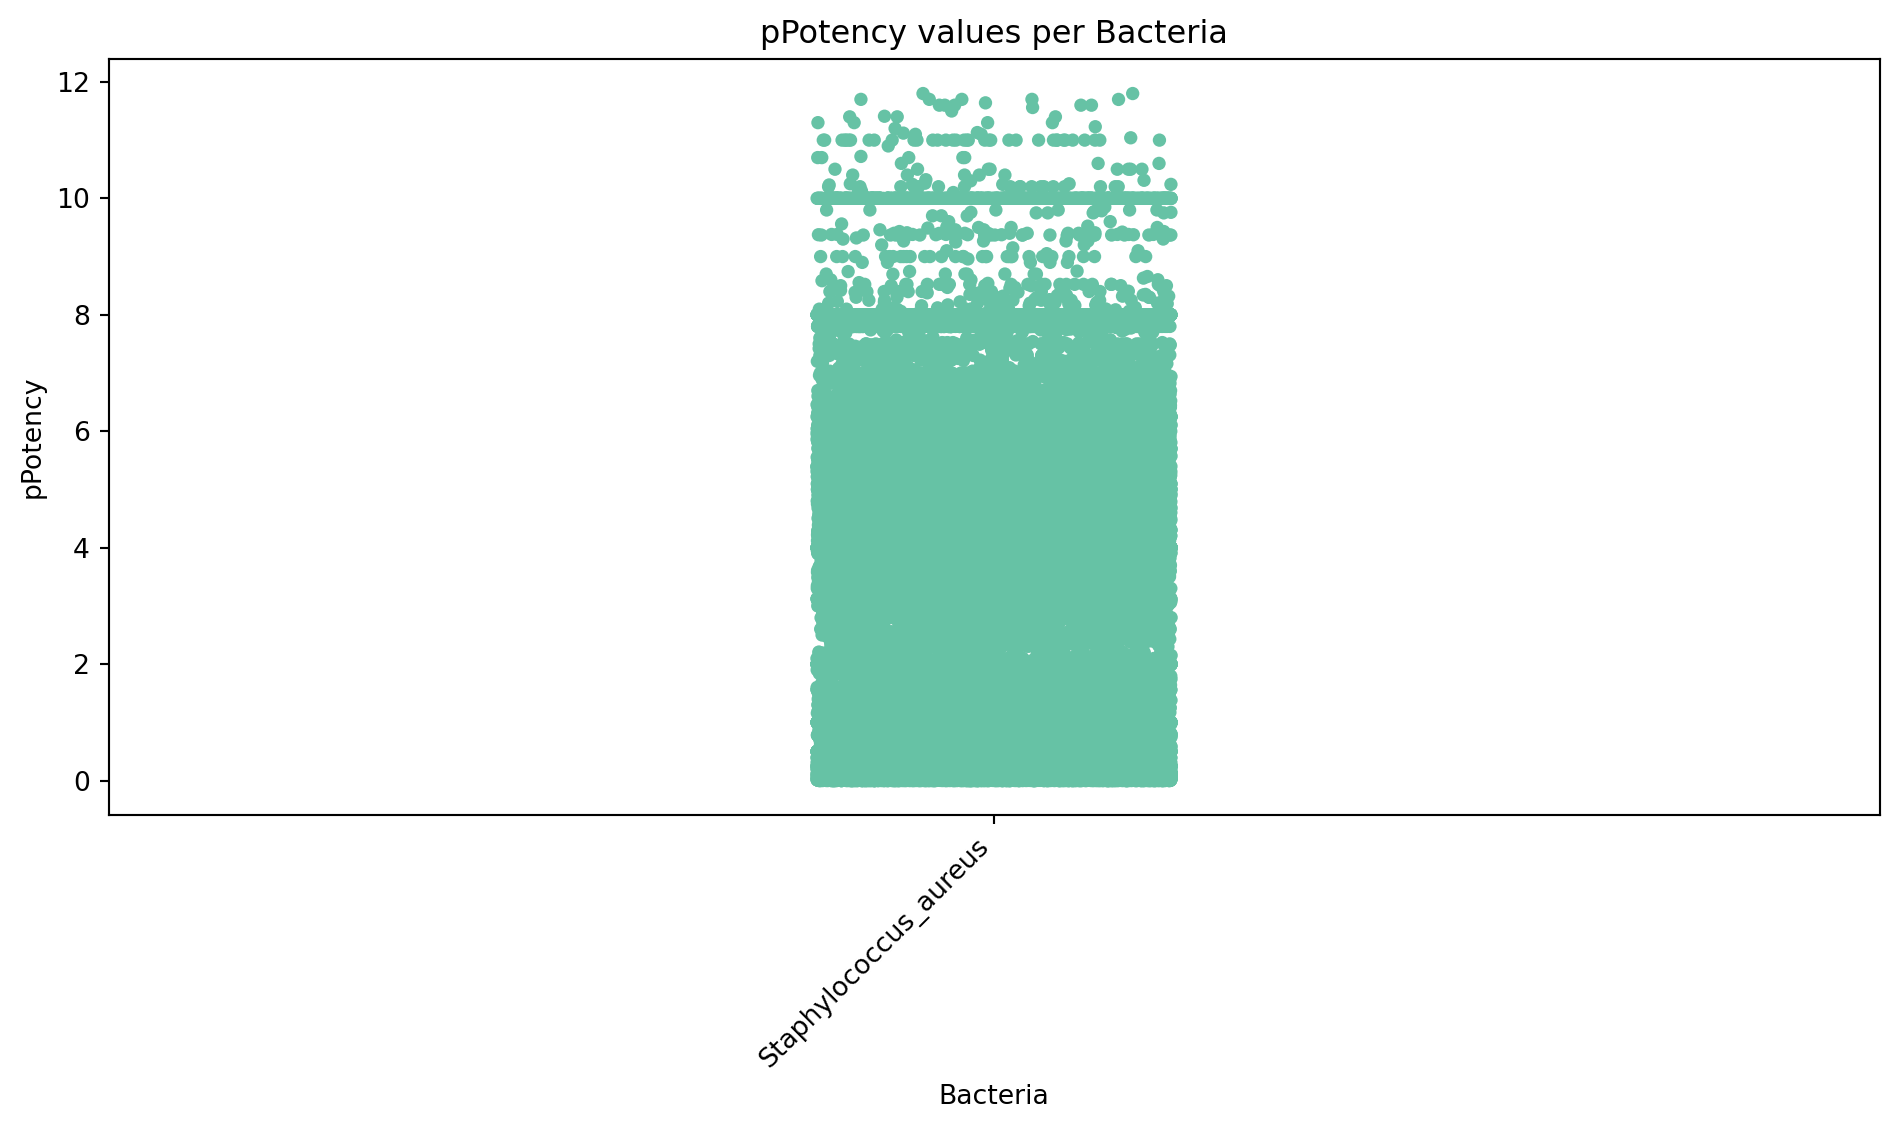

In [55]:
plt.figure(figsize=(10, 6))
sns.stripplot(
    data=StaphylococcusBacteriaData_chEMBL_wMACAW,
    x='BacteriaClassifier',
    y='pPotency',
    jitter=True,          # spreads the dots to avoid overlap
    palette='Set2',
    alpha=1
)
plt.xticks(rotation=45, ha='right')
plt.title('pPotency values per Bacteria')
plt.xlabel('Bacteria')
plt.ylabel('pPotency')
plt.tight_layout()
plt.show()

### Clip first 1000 rows from the data set for fast testing

### Train ML Model

In [56]:
# df = StaphylococcusBacteriaData_chEMBL_wMACAW
Y = StaphylococcusBacteriaData_chEMBL_wMACAW.pPotency
smiles = StaphylococcusBacteriaData_chEMBL_wMACAW.Smiles

In [57]:
print(len(smiles))

90807


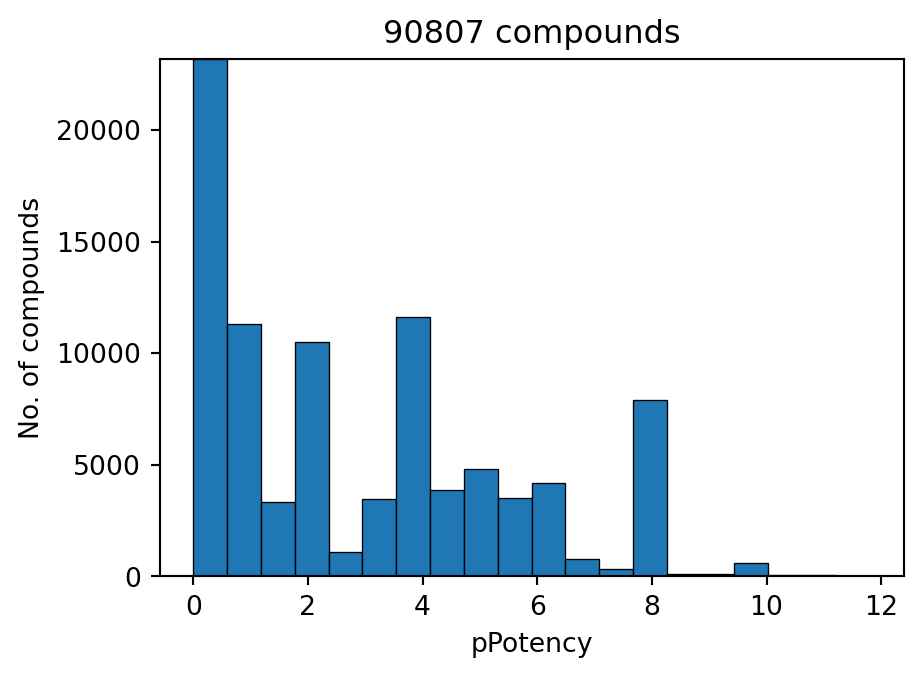

In [58]:
plot_histogram(Y, xlabel="pPotency")

Define the partitions for cross-validation.

In [59]:
num_of_partitions = 10
kf = KFold(n_splits=num_of_partitions, shuffle=True, random_state=42)

Define hyperparameters for SVR:

In [60]:
param_grid = {
    'C': [1, 5, 7, 10, 30, 50, 100, 300, 500], 
    'epsilon': [0.1, 0.3, 1, 3, 5, 10, 20],
    'kernel': ['rbf']
}

Define MACAW embedding:

In [61]:
mcw = MACAW(
    type_fp='atompairs', 
    metric='sokal', 
    n_components=15, 
    n_landmarks=200, 
    random_state=39
)


After cleaning NaN values, reset the indices

In [62]:
valid_mask = Y.notna()
smiles = smiles[valid_mask].reset_index(drop=True)  
Y = Y[valid_mask].reset_index(drop=True)            

print(f"Cleaned data has: {len(smiles)} samples")
print(f"Y index: {Y.index[:10].tolist()}")  

Cleaned data has: 90807 samples
Y index: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


### Create directory to save plot

In [63]:
save_path = resultsDir + 'StaphylococcusBacteria/StaphylococcusBacteria_CV_testOnly.svg'
os.makedirs(os.path.dirname(save_path), exist_ok=True)

### ML predictions with Test only results

### ML predictions with Train + Test results

In [64]:
commandLineData_train = pd.read_csv( resultsDir + 'StaphylococcusBacteriaCommandline_10fold/predictions_train_SVR.csv')
Y_obs_train = commandLineData_train['Observed'].values
Y_cv_pred_train = commandLineData_train['Predicted'].values

In [65]:
commandLineData_test = pd.read_csv( resultsDir + 'StaphylococcusBacteriaCommandline_10fold/predictions_test_SVR.csv')
Y_obs_test = commandLineData_test['Observed'].values
Y_cv_pred_test = commandLineData_test['Predicted'].values

Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/StaphylococcusBacteria/StaphylococcusBacteria_CV_TrTs.svg
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/StaphylococcusBacteria/StaphylococcusBacteria_CV_TrTs.png


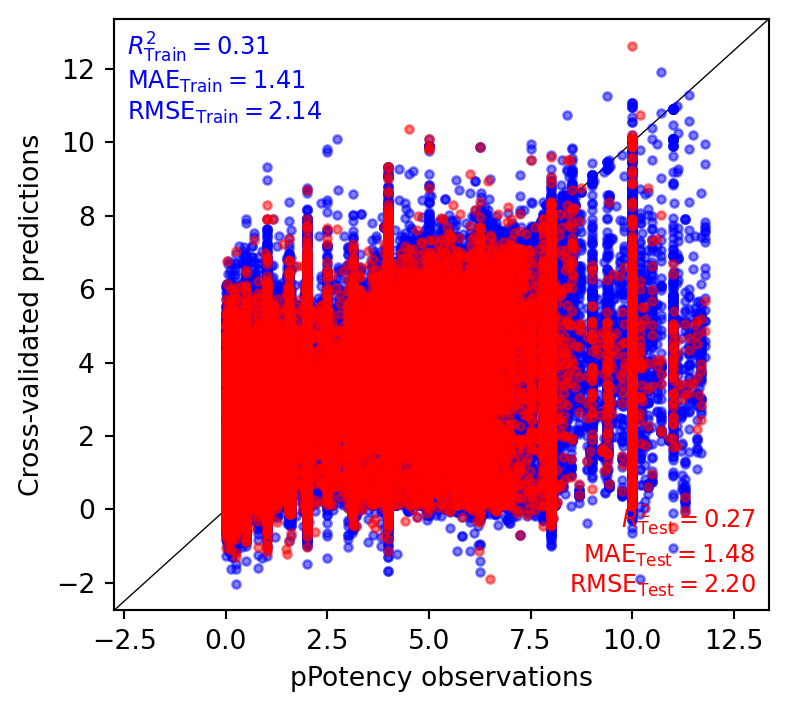

In [66]:
parity_plot(x=Y_obs_train, 
            y=Y_cv_pred_train, 
            x_test=Y_obs_test, 
            y_test=Y_cv_pred_test, 
            xlabel="pPotency observations", 
            ylabel="Cross-validated predictions",
            savetitle=resultsDir + 'StaphylococcusBacteria/StaphylococcusBacteria_CV_TrTs.svg',
            save_formats=['svg', 'png'])

Generate a model trained on the whole data set, to be used for prediction tasks

### Optimize hyperparameters

### Train/test split

In [67]:
commandLineData_train = pd.read_csv( resultsDir + 'StaphylococcusBacteriaCommandline_10fold/fullData_train_predictions.csv')
Y_obs_train = commandLineData_train['Y_observed'].values
Y_cv_pred_train = commandLineData_train['Y_predicted'].values

In [68]:
commandLineData_test = pd.read_csv( resultsDir + 'StaphylococcusBacteriaCommandline_10fold/fullData_test_predictions.csv')
Y_obs_test = commandLineData_test['Y_observed'].values
Y_cv_pred_test = commandLineData_test['Y_observed'].values

Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/StaphylococcusBacteria/StaphylococcusBacteria_fullData_TrTs.svg
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/StaphylococcusBacteria/StaphylococcusBacteria_fullData_TrTs.png


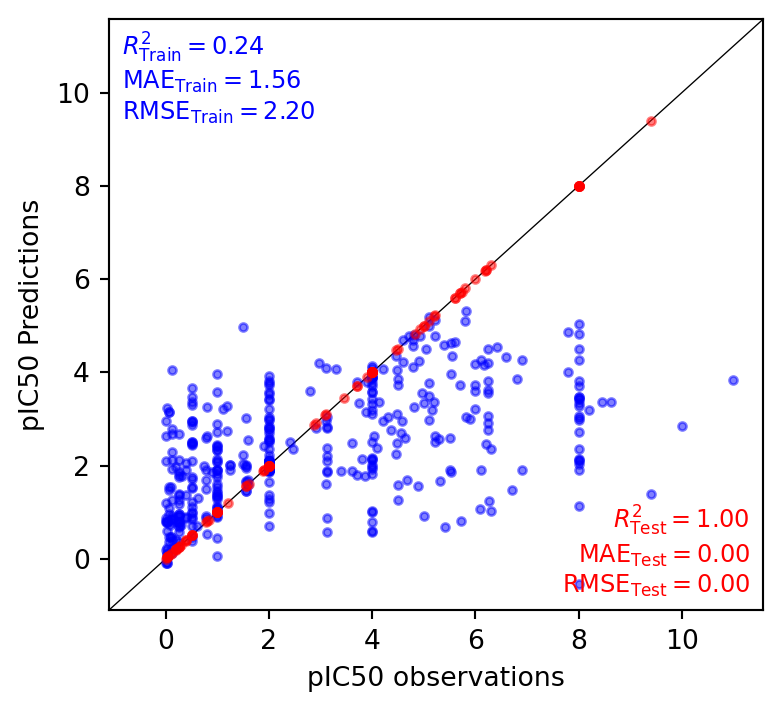

In [70]:
parity_plot(x=Y_obs_train, 
            y=Y_cv_pred_train, 
            x_test=Y_obs_test, 
            y_test=Y_cv_pred_test,             # predicted test (held-out)
            xlabel="pIC50 observations",
            ylabel="pIC50 Predictions",
            savetitle=resultsDir + 'StaphylococcusBacteria/StaphylococcusBacteria_fullData_TrTs.svg',
            save_formats=['svg', 'png']
)

## 2. Discovery of new hits specific to all Bacteriaes (data source Enamine_antiviralsData.csv)

In this section, we screen a custom virtual library looking for molecules that are promising accoring to the the SVR models `regr` above, which use 15-D MACAW embeddings as their input. The custom library ("Enamine_antiviralsData.csv") compiled from commercial catalogs by Enamine. In particular, we are interested in molecules with high predicted pPotency.

In [71]:
EnamineAntibacterialsData = pd.read_csv(dataDir + "Enamine_Antibacterial_Library_plated_32000cmpds_20251019.csv",
                                    sep=",", comment=None, skipinitialspace=True, engine="python", encoding="utf-8",          
                                     skiprows=1, skip_blank_lines=True)
print(EnamineAntibacterialsData.shape)
smi_lib = EnamineAntibacterialsData.SMILES
print(f"Total compounds to screen: {len(smi_lib)}")
EnamineAntibacterialsData.head()

(32000, 11)
Total compounds to screen: 32000


,SMILES,Catalog ID,MW,MW (desalted),ClogP,logS,HBD,HBA,TPSA,RotBonds,AnalogsFromREAL
0,CC1=NN=C(COC(=O)C=2C=CC(=C(C2)[N+]([O-])=O)N3C...,Z19065527,374.392,374.392,2.754,-4.286,0,6,111.60,6,https://real.enamine.net/public-enum-files/Z19...
1,CC1=NC2=NC(=NN2C(C)=C1C)SCCCOC(=O)NC(N)=O,Z1203040657,338.387,338.387,1.246,-4.006,2,5,124.50,8,https://real.enamine.net/public-enum-files/Z12...
2,CC=1C=CC(=CC1)S(=O)(=O)NCC(=O)OCC(=O)N2CC(C)OC...,Z19154552,384.449,384.449,2.021,-3.375,1,5,102.01,6,https://real.enamine.net/public-enum-files/Z19...
3,CC(C)N1C=NC(=C1)S(=O)(=O)NC=2C=CN(CC=3C=CC=CN3)N2,Z1509821346,346.409,346.409,1.094,-1.970,1,5,94.70,6,https://real.enamine.net/public-enum-files/Z15...
4,O=C(O)CC=1C=CC(=CC1)S(=O)(=O)NC=2C=CC(Cl)=CC2O,Z1509833014,341.768,341.768,2.254,-3.235,3,5,103.70,4,https://real.enamine.net/public-enum-files/Z15...


Load pre-trained models

In [73]:
print("Loading trained models")
regr_file_path = resultsDir + 'StaphylococcusBacteriaCommandline_10fold/fullData_regr_pred.joblib'
macaw_file_path = resultsDir + 'StaphylococcusBacteriaCommandline_10fold/fullData_macaw_model.joblib'

regr_pred = load(regr_file_path)
mcw = load(macaw_file_path)
print(f"Loaded: {regr_file_path}")
print(f"Loaded: {macaw_file_path}")

Loading trained models
Loaded: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/StaphylococcusBacteriaCommandline_10fold/fullData_regr_pred.joblib
Loaded: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/StaphylococcusBacteriaCommandline_10fold/fullData_macaw_model.joblib


Generate MACAW embeddings

In [74]:
print("\nComputing MACAW embeddings")
X1_lib = mcw.transform(smi_lib)
print(f"Embedding shape: {X1_lib.shape}")


Computing MACAW embeddings
Embedding shape: (32000, 15)


Predict pPotency

In [75]:
print("Generating predictions")
Y1_lib_pred = regr_pred.predict(X1_lib)
print(f"Predictions shape: {Y1_lib_pred.shape}")

Generating predictions
Predictions shape: (32000,)


Add predictions to dataframe

In [76]:
EnamineAntibacterialsData_predicted = EnamineAntibacterialsData.copy()
EnamineAntibacterialsData_predicted['pPotency_prediction'] = Y1_lib_pred

# Convert pPotency to IC50 (M)
# pPotency = -log10(IC50), so IC50 = 10^(-pPotency)
EnamineAntibacterialsData_predicted['IC50 (M)'] = 10 ** (-EnamineAntibacterialsData_predicted['pPotency_prediction'])

EnamineAntibacterialsData_predicted = EnamineAntibacterialsData_predicted.filter(
    items=["SMILES", "pPotency_prediction", "IC50 (M)"]
)
EnamineAntibacterialsData_predicted

,SMILES,pPotency_prediction,IC50 (M)
0,CC1=NN=C(COC(=O)C=2C=CC(=C(C2)[N+]([O-])=O)N3C...,1.028759,0.093593
1,CC1=NC2=NC(=NN2C(C)=C1C)SCCCOC(=O)NC(N)=O,1.524181,0.029910
2,CC=1C=CC(=CC1)S(=O)(=O)NCC(=O)OCC(=O)N2CC(C)OC...,1.897278,0.012668
3,CC(C)N1C=NC(=C1)S(=O)(=O)NC=2C=CN(CC=3C=CC=CN3)N2,2.605955,0.002478
4,O=C(O)CC=1C=CC(=CC1)S(=O)(=O)NC=2C=CC(Cl)=CC2O,4.171359,0.000067
...,...,...,...
31995,CCOCCCOC(=O)C1=CC(=C(C)S1)[N+]([O-])=O,2.872342,0.001342
31996,CC(C)C(NS(=O)(=O)CC12CCC(CC1=O)C2(C)C)C(N)=O,1.531069,0.029440
31997,CNC(=O)CN1CCC(CC1)NS(=O)(=O)CCCC(F)(F)F,2.659885,0.002188
31998,CCOC(=O)NC1CCCN(C1)C(=O)C2=CC(=NN2C3CC3)C(F)(F)F,1.285251,0.051850


Let us represent the predictions of both models:

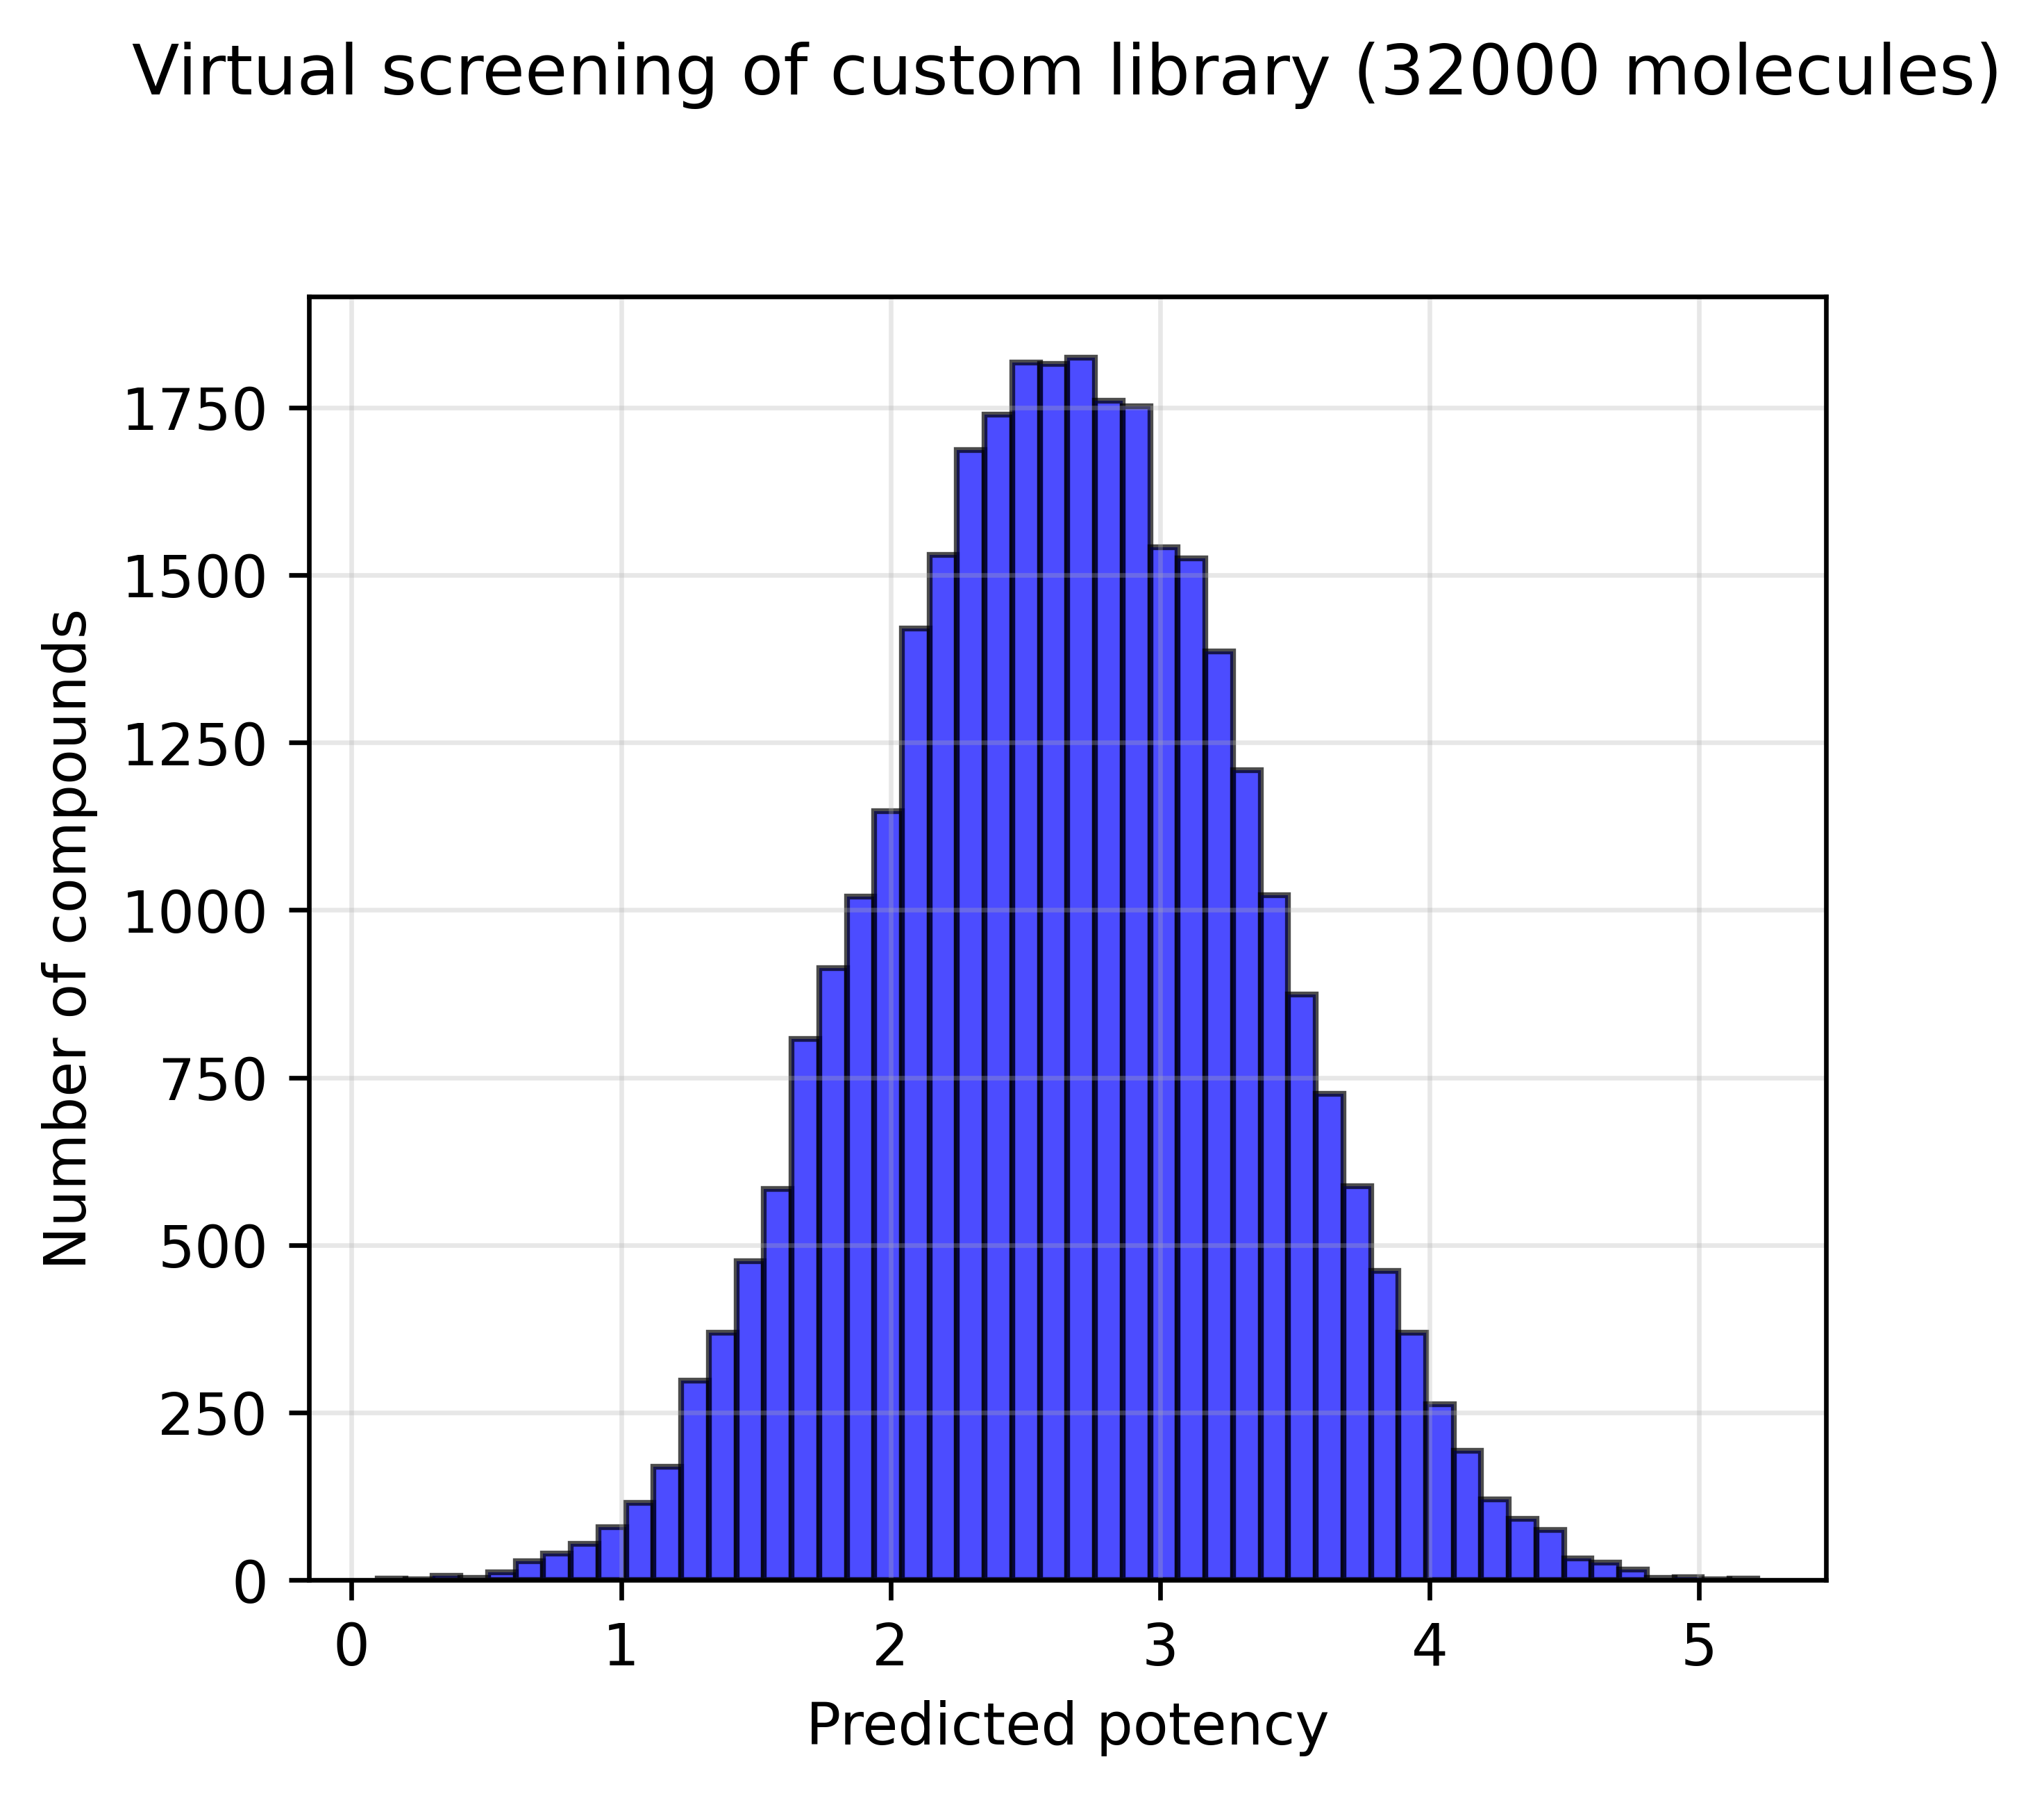

In [78]:
plt.figure(figsize=(4.7, 4.0), dpi=300)
plt.hist(Y1_lib_pred, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.xlabel("Predicted potency")
plt.ylabel("Number of compounds")
plt.title(f"Virtual screening of custom library ({len(smi_lib)} molecules)", pad=35)
#plt.axvline(x=5, color='r', linestyle='--', linewidth=2, label='pPotency = 5.0 (minimum)') 
#plt.axvline(x=6, color='g', linestyle='--', linewidth=2, label='pPotency = 6.0 (good)')
#plt.axvline(x=7, color='b', linestyle='--', linewidth=2, label='pPotency = 7.0 (excellent)')

# Legend on top, outside plot area
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.13), ncol=3, frameon=False)

plt.grid(True, alpha=0.3)
plt.savefig(resultsDir + 'StaphylococcusBacteria/StaphylococcusBacteria_validation.svg', bbox_inches='tight', dpi=300)
plt.savefig(resultsDir + 'StaphylococcusBacteria/StaphylococcusBacteria_validation.png', bbox_inches='tight', dpi=300)
plt.show()

Let us have a look at the compounds:

In [79]:
# Define multiple priority levels
high_priority_idx = np.where(Y1_lib_pred >= 7)[0]
medium_priority_idx = np.where((Y1_lib_pred >= 6.0) & (Y1_lib_pred < 7.0))[0]
low_priority_idx = np.where((Y1_lib_pred >= 5.0) & (Y1_lib_pred < 6))[0]

print(f"High priority (pPotency ≥ 7.0): {len(high_priority_idx)} compounds")
print(f"Medium priority (6 ≤ pPotency < 7.0): {len(medium_priority_idx)} compounds")
print(f"Low priority (5 ≤ pPotency < 6): {len(low_priority_idx)} compounds")

# Use the one you need
idx = high_priority_idx  # or combine them

High priority (pPotency ≥ 7.0): 0 compounds
Medium priority (6 ≤ pPotency < 7.0): 0 compounds
Low priority (5 ≤ pPotency < 6): 3 compounds


In [80]:
EnamineAntibacterialsData_final = EnamineAntibacterialsData.iloc[idx].copy()
EnamineAntibacterialsData_final['pPotency_prediction'] = Y1_lib_pred[idx]

EnamineAntibacterialsData_final

,SMILES,Catalog ID,MW,MW (desalted),ClogP,logS,HBD,HBA,TPSA,RotBonds,AnalogsFromREAL,pPotency_prediction


In [ ]:
molecules = [Chem.MolFromSmiles(smi) for smi in EnamineAntibacterialsData_final.SMILES[:50]]

Draw.MolsToGridImage(molecules, subImgSize=(200,200), molsPerRow=3, useSVG=True)

### Top 20 compounds with higher pPotency

In [84]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Get the cutoff pPotency (minimum value in top 20)
cutoff_pPotency = Y1_lib_pred[top_20_idx[-1]]  # Last (20th) value

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f}")
print(f"Highest predicted pPotency: {Y1_lib_pred[top_20_idx[0]]:.2f}")
print(f"Range of top 20: {cutoff_pPotency:.2f} - {Y1_lib_pred[top_20_idx[0]]:.2f}")

Top 20 compounds cutoff pPotency: 4.75
Highest predicted pPotency: 5.21
Range of top 20: 4.75 - 5.21


In [87]:
# Get top 20 indices by highest predicted pPotency
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Create dataframe with top 20
EnamineAntibacterialsData_top20 = EnamineAntibacterialsData.iloc[top_20_idx].copy()

# Add pPotency_prediction rounded to 3 decimal places
EnamineAntibacterialsData_top20['pPotency_prediction'] = Y1_lib_pred[top_20_idx].round(3)

# Add IC50 column (convert pPotency to Molar units)
# IC50 (M) = 10^(-pPotency)
EnamineAntibacterialsData_top20['IC50 (M)'] = 10**(-Y1_lib_pred[top_20_idx])

# Add rank column at the beginning
EnamineAntibacterialsData_top20.insert(0, 'Rank', range(1, 21))

# Calculate ranges
pPotency_max = Y1_lib_pred[top_20_idx[0]]   # Highest (best)
pPotency_min = Y1_lib_pred[top_20_idx[-1]]  # Lowest (cutoff)
IC50_min = 10**(-pPotency_max)              # Lowest IC50 (most potent)
IC50_max = 10**(-pPotency_min)              # Highest IC50 (least potent in top 20)
IC50_min_nM = IC50_min * 1e9
IC50_max_nM = IC50_max * 1e9

# Display information
print("-"*70)
print("Top 20 Compounds with Highest Predicted pPotency")
print("-"*70)
print("\nCutoff Values (20th ranked compound):")
print(f"  pPotency:    {pPotency_min:.3f}")
print(f"  IC50:        {IC50_max:.3e} M  ({IC50_max_nM:.2f} nM)")

print("\nBest Values (1st ranked compound):")
print(f"  pPotency:    {pPotency_max:.3f}")
print(f"  IC50:        {IC50_min:.3e} M  ({IC50_min_nM:.2f} nM)")


print("\n Range for Top 20 Compounds:")
print(f"pPotency Range:  {pPotency_min:.3f} - {pPotency_max:.3f}")
print(f"\nIC50 Range (M):  {IC50_max:.3e} - {IC50_min:.3e}")
#print(f"IC50 Range (nM): {IC50_max_nM:.2f} - {IC50_min_nM:.2f} nM")
#print(f"                 (Δ = {pPotency_max - pPotency_min:.3f})")
#print(f"                 (Fold change = {IC50_max/IC50_min:.1f}x)")


# Set pandas display options for scientific notation
pd.options.display.float_format = lambda x: f'{x:.3e}' if abs(x) < 0.01 or abs(x) > 1000 else f'{x:.3f}'

# Display the dataframe
EnamineAntibacterialsData_top20 = EnamineAntibacterialsData_top20.filter(
    items=["Rank", "SMILES", "pPotency_prediction", "IC50 (M)"]
)
EnamineAntibacterialsData_top20

----------------------------------------------------------------------
Top 20 Compounds with Highest Predicted pPotency
----------------------------------------------------------------------

Cutoff Values (20th ranked compound):
  pPotency:    4.748
  IC50:        1.785e-05 M  (17846.72 nM)

Best Values (1st ranked compound):
  pPotency:    5.215
  IC50:        6.096e-06 M  (6096.37 nM)

 Range for Top 20 Compounds:
pPotency Range:  4.748 - 5.215

IC50 Range (M):  1.785e-05 - 6.096e-06


,Rank,SMILES,pPotency_prediction,IC50 (M)
23164,1,[O-][N+](=O)C=1C=CC=C(C1)S(=O)(=O)CCC=2C=CC=CC2,5.215,6.096e-06
28031,2,[O-][N+](=O)C=1C=CC=C(C1)CNC2(CO)CCC=3C=CC=CC32,5.127,7.473e-06
3955,3,Cl.NCCC(=O)N(CC=1C=CC=CC1)C=2C=CC=CC2,5.099,7.955e-06
24599,4,[O-][N+](=O)C=1C=CC(=CC1)CCNC=2C=CC=3COCC3C2,4.989,1.025e-05
3902,5,Cl.NCCC=1C=CC(=CC1)C(=O)OC=2C=CC=CC2,4.982,1.042e-05
21125,6,[O-][N+](=O)C=1C=CC(=NC1)N(CCO)CCC=2C=CC=CC2,4.927,1.184e-05
2654,7,Cl.NCCC=1C=CC(=CC1)OCC=2C=CC=CC2,4.926,1.186e-05
11075,8,O=C(O)CCNS(=O)(=O)C=1C=CC(=CC1)OC=2C=CC=CC2,4.835,1.461e-05
20102,9,NS(=O)(=O)CCCS(=O)CC1=CC=CC=2C=CC=CC12,4.826,1.493e-05
6700,10,COC=1C=CC=CC1CCNC=2C=CC(=CC2)[N+]([O-])=O,4.823,1.503e-05


 Saved PNG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/StaphylococcusBacteria/StaphylococcusBacteria_predictedCompounds.png
 Saved SVG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/StaphylococcusBacteria/StaphylococcusBacteria_predictedCompounds.svg


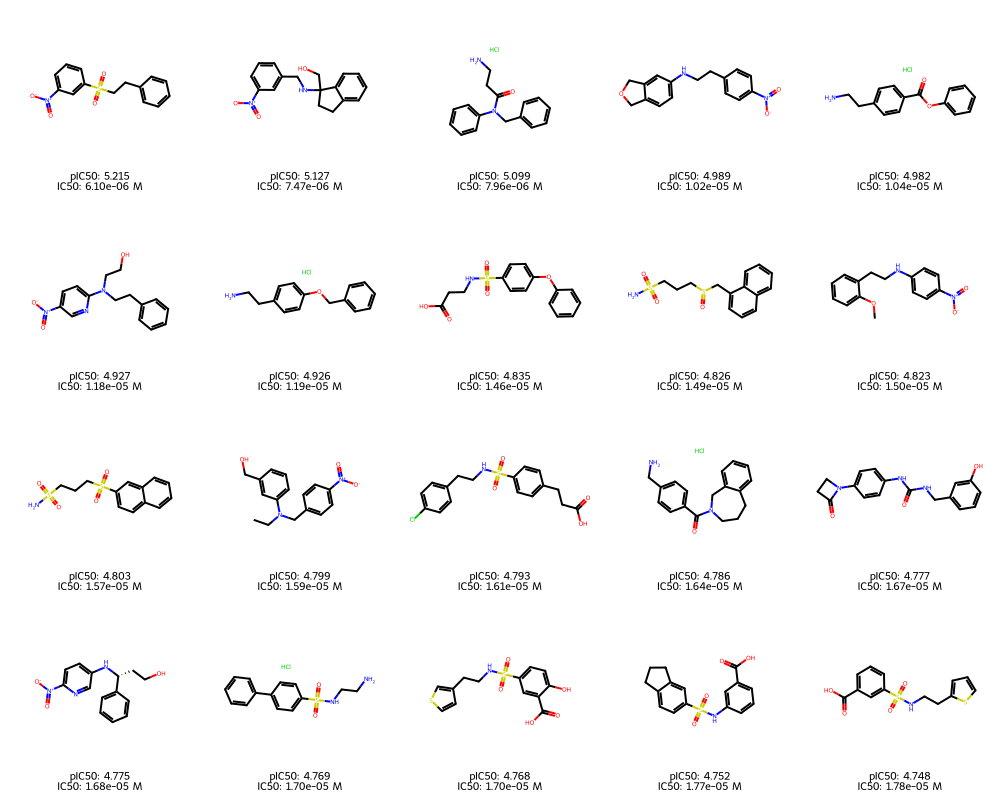

In [88]:
from rdkit import Chem
from rdkit.Chem import Draw
import os
from PIL import Image

# Setup paths
output_dir = resultsDir + 'StaphylococcusBacteria/'
os.makedirs(output_dir, exist_ok=True)

# Get molecules
molecules = [Chem.MolFromSmiles(smi) for smi in EnamineAntibacterialsData_top20.SMILES[:50]]

# Create legends
legends = []
for idx, row in EnamineAntibacterialsData_top20[:50].iterrows():
    legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (M)']:.2e} M"
    legends.append(legend)

# Generate PNG image
img = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=False, 
    legends=legends,
    returnPNG=False  # Returns PIL Image object
)

# Save PNG
output_png = output_dir + 'StaphylococcusBacteria_predictedCompounds.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

# Generate and save SVG
svg = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=True,
    legends=legends
)

output_svg = output_dir + 'StaphylococcusBacteria_predictedCompounds.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")


display(img)  

### 2.2 Discovery of new hits specific to Staphylococcus (data source Life chemicals data set)

In this section, we screen a custom virtual library looking for molecules that are promising accoring to the the SVR models regr above, which use 15-D MACAW embeddings as their input. The custom library compiled from commercial catalogs by Life chemicals. In particular, we are interested in molecules with high predicted pPotency.

In [91]:
# Read all molecules from SDF
supplier = Chem.SDMolSupplier(dataDir + "LC_Antibacterial_Focused_Library.sdf")
mols = [mol for mol in supplier if mol is not None]

# Extract properties into DataFrame
records = []
for mol in mols:
    props = mol.GetPropsAsDict()
    props["SMILES"] = Chem.MolToSmiles(mol)
    records.append(props)

LCAntibacterialsData = pd.DataFrame(records)

print(f"\nOriginal shape: {LCAntibacterialsData.shape}")

# Show duplicate SMILES if any
duplicates = LCAntibacterialsData[LCAntibacterialsData.duplicated(subset='SMILES', keep=False)]
if len(duplicates) > 0:
    print(f"\nFound {duplicates['SMILES'].nunique()} SMILES that appear multiple times:")
    print(duplicates.groupby('SMILES').size().sort_values(ascending=False).head(10))

# Remove duplicates (keep first occurrence)
LCAntibacterialsData = LCAntibacterialsData.drop_duplicates(subset='SMILES', keep='first')

print(f"\nAfter removing duplicates: {LCAntibacterialsData.shape}")
smi_lib = LCAntibacterialsData.SMILES
print(f"Total compounds to screen: {len(smi_lib)}")
LCAntibacterialsData.head()


Original shape: (15538, 26)

Found 3 SMILES that appear multiple times:
SMILES
CC(N)C(=O)O         2
CNC(CO)Cc1ccccc1    2
CNCC(O)c1ccccc1     2
dtype: int64

After removing duplicates: (15535, 26)
Total compounds to screen: 15535


,IDNUMBER,Chemical_Name,CAS,PriceCoeff,MW,Description,FSP3,clogP,TPSA,H-acceptors,...,Reference_ID,Activity_type,Activity_value_,Activity_units_,Activity_comment,Target_name,Target_organism,Target_type,SMILES,PPDS
0,F6540-4248,"6-(3-methoxypiperidin-1-yl)-N,N-dimethylpyrimi...",2097927-68-7,1.500,236.310,oil,0.670,1.600,41.490,3,...,CHEMBL4548594,Inhibition,37.210,%,Average; N=1,Pseudomonas aeruginosa,Pseudomonas aeruginosa,ORGANISM,COC1CCCN(c2cc(N(C)C)ncn2)C1,NaN
1,F6541-0830,"1-(5,6,7,8-tetrahydroquinazolin-4-yl)piperidin...",1541766-76-0,1.500,233.310,oil,0.690,1.510,49.250,3,...,CHEMBL4533334,Inhibition,26.560,%,Average; N=1,Pseudomonas aeruginosa,Pseudomonas aeruginosa,ORGANISM,OC1CCCN(c2ncnc3c2CCCC3)C1,NaN
2,F6541-5261,5-fluoro-2-[4-(propan-2-yl)piperazin-1-yl]pyri...,2034458-11-0,1.500,224.280,oil,0.640,1.460,32.260,3,...,CHEMBL4542429,Inhibition,25.160,%,Average; N=1,Pseudomonas aeruginosa,Pseudomonas aeruginosa,ORGANISM,CC(C)N1CCN(c2ncc(F)cn2)CC1,NaN
3,F6543-7286,"6-(2,6-dimethylmorpholin-4-yl)-N,N-dimethylpyr...",2034461-31-7,1.500,236.310,solid,0.670,1.830,41.490,3,...,CHEMBL4548594,Inhibition,37.210,%,Average; N=1,Pseudomonas aeruginosa,Pseudomonas aeruginosa,ORGANISM,CC1CN(c2cc(N(C)C)ncn2)CC(C)O1,NaN
4,F6570-1027,1-[6-(dimethylamino)pyrimidin-4-yl]piperidin-3-ol,1903487-65-9,1.500,222.280,solid,0.640,0.840,52.490,3,...,CHEMBL4548594,Inhibition,37.210,%,Average; N=1,Pseudomonas aeruginosa,Pseudomonas aeruginosa,ORGANISM,CN(C)c1cc(N2CCCC(O)C2)ncn1,NaN


In [92]:
print("\nComputing MACAW embeddings")
X1_lib = mcw.transform(smi_lib)
print(f"Embedding shape: {X1_lib.shape}")


Computing MACAW embeddings
Embedding shape: (15535, 15)


In [93]:
print("Generating predictions")
Y1_lib_pred = regr_pred.predict(X1_lib)
print(f"Predictions shape: {Y1_lib_pred.shape}")

Generating predictions
Predictions shape: (15535,)


In [94]:
LCAntibacterialsData_predicted = LCAntibacterialsData.copy()
LCAntibacterialsData_predicted['pPotency_prediction'] = Y1_lib_pred

# Convert pPotency to IC50 (M)
# pPotency = -log10(IC50), so IC50 = 10^(-pPotency)
LCAntibacterialsData_predicted['IC50 (M)'] = 10 ** (-LCAntibacterialsData_predicted['pPotency_prediction'])

LCAntibacterialsData_predicted = LCAntibacterialsData_predicted.filter(
    items=["SMILES", "pPotency_prediction", "IC50 (M)"]
)
LCAntibacterialsData_predicted

,SMILES,pPotency_prediction,IC50 (M)
0,COC1CCCN(c2cc(N(C)C)ncn2)C1,3.288,5.147e-04
1,OC1CCCN(c2ncnc3c2CCCC3)C1,3.539,2.894e-04
2,CC(C)N1CCN(c2ncc(F)cn2)CC1,3.417,3.828e-04
3,CC1CN(c2cc(N(C)C)ncn2)CC(C)O1,2.502,3.150e-03
4,CN(C)c1cc(N2CCCC(O)C2)ncn1,3.387,4.099e-04
...,...,...,...
15533,O=C1c2cccc3cccc(c23)C(=O)N1CCCN(C(=O)c1ccc(-c2...,3.139,7.266e-04
15534,O=C1Nc2ccc(S(=O)(=O)Nc3ccc(NS(=O)(=O)c4ccc5c6c...,3.192,6.431e-04
15535,Cc1ncc(CO)c2cc(C(=O)Nc3cccc4ccccc34)/c(=N/c3cc...,3.048,8.957e-04
15536,CCOC(=O)c1sc(NC(=O)c2ccc(Oc3ccc(C(=O)Nc4nc(-c5...,3.310,4.899e-04


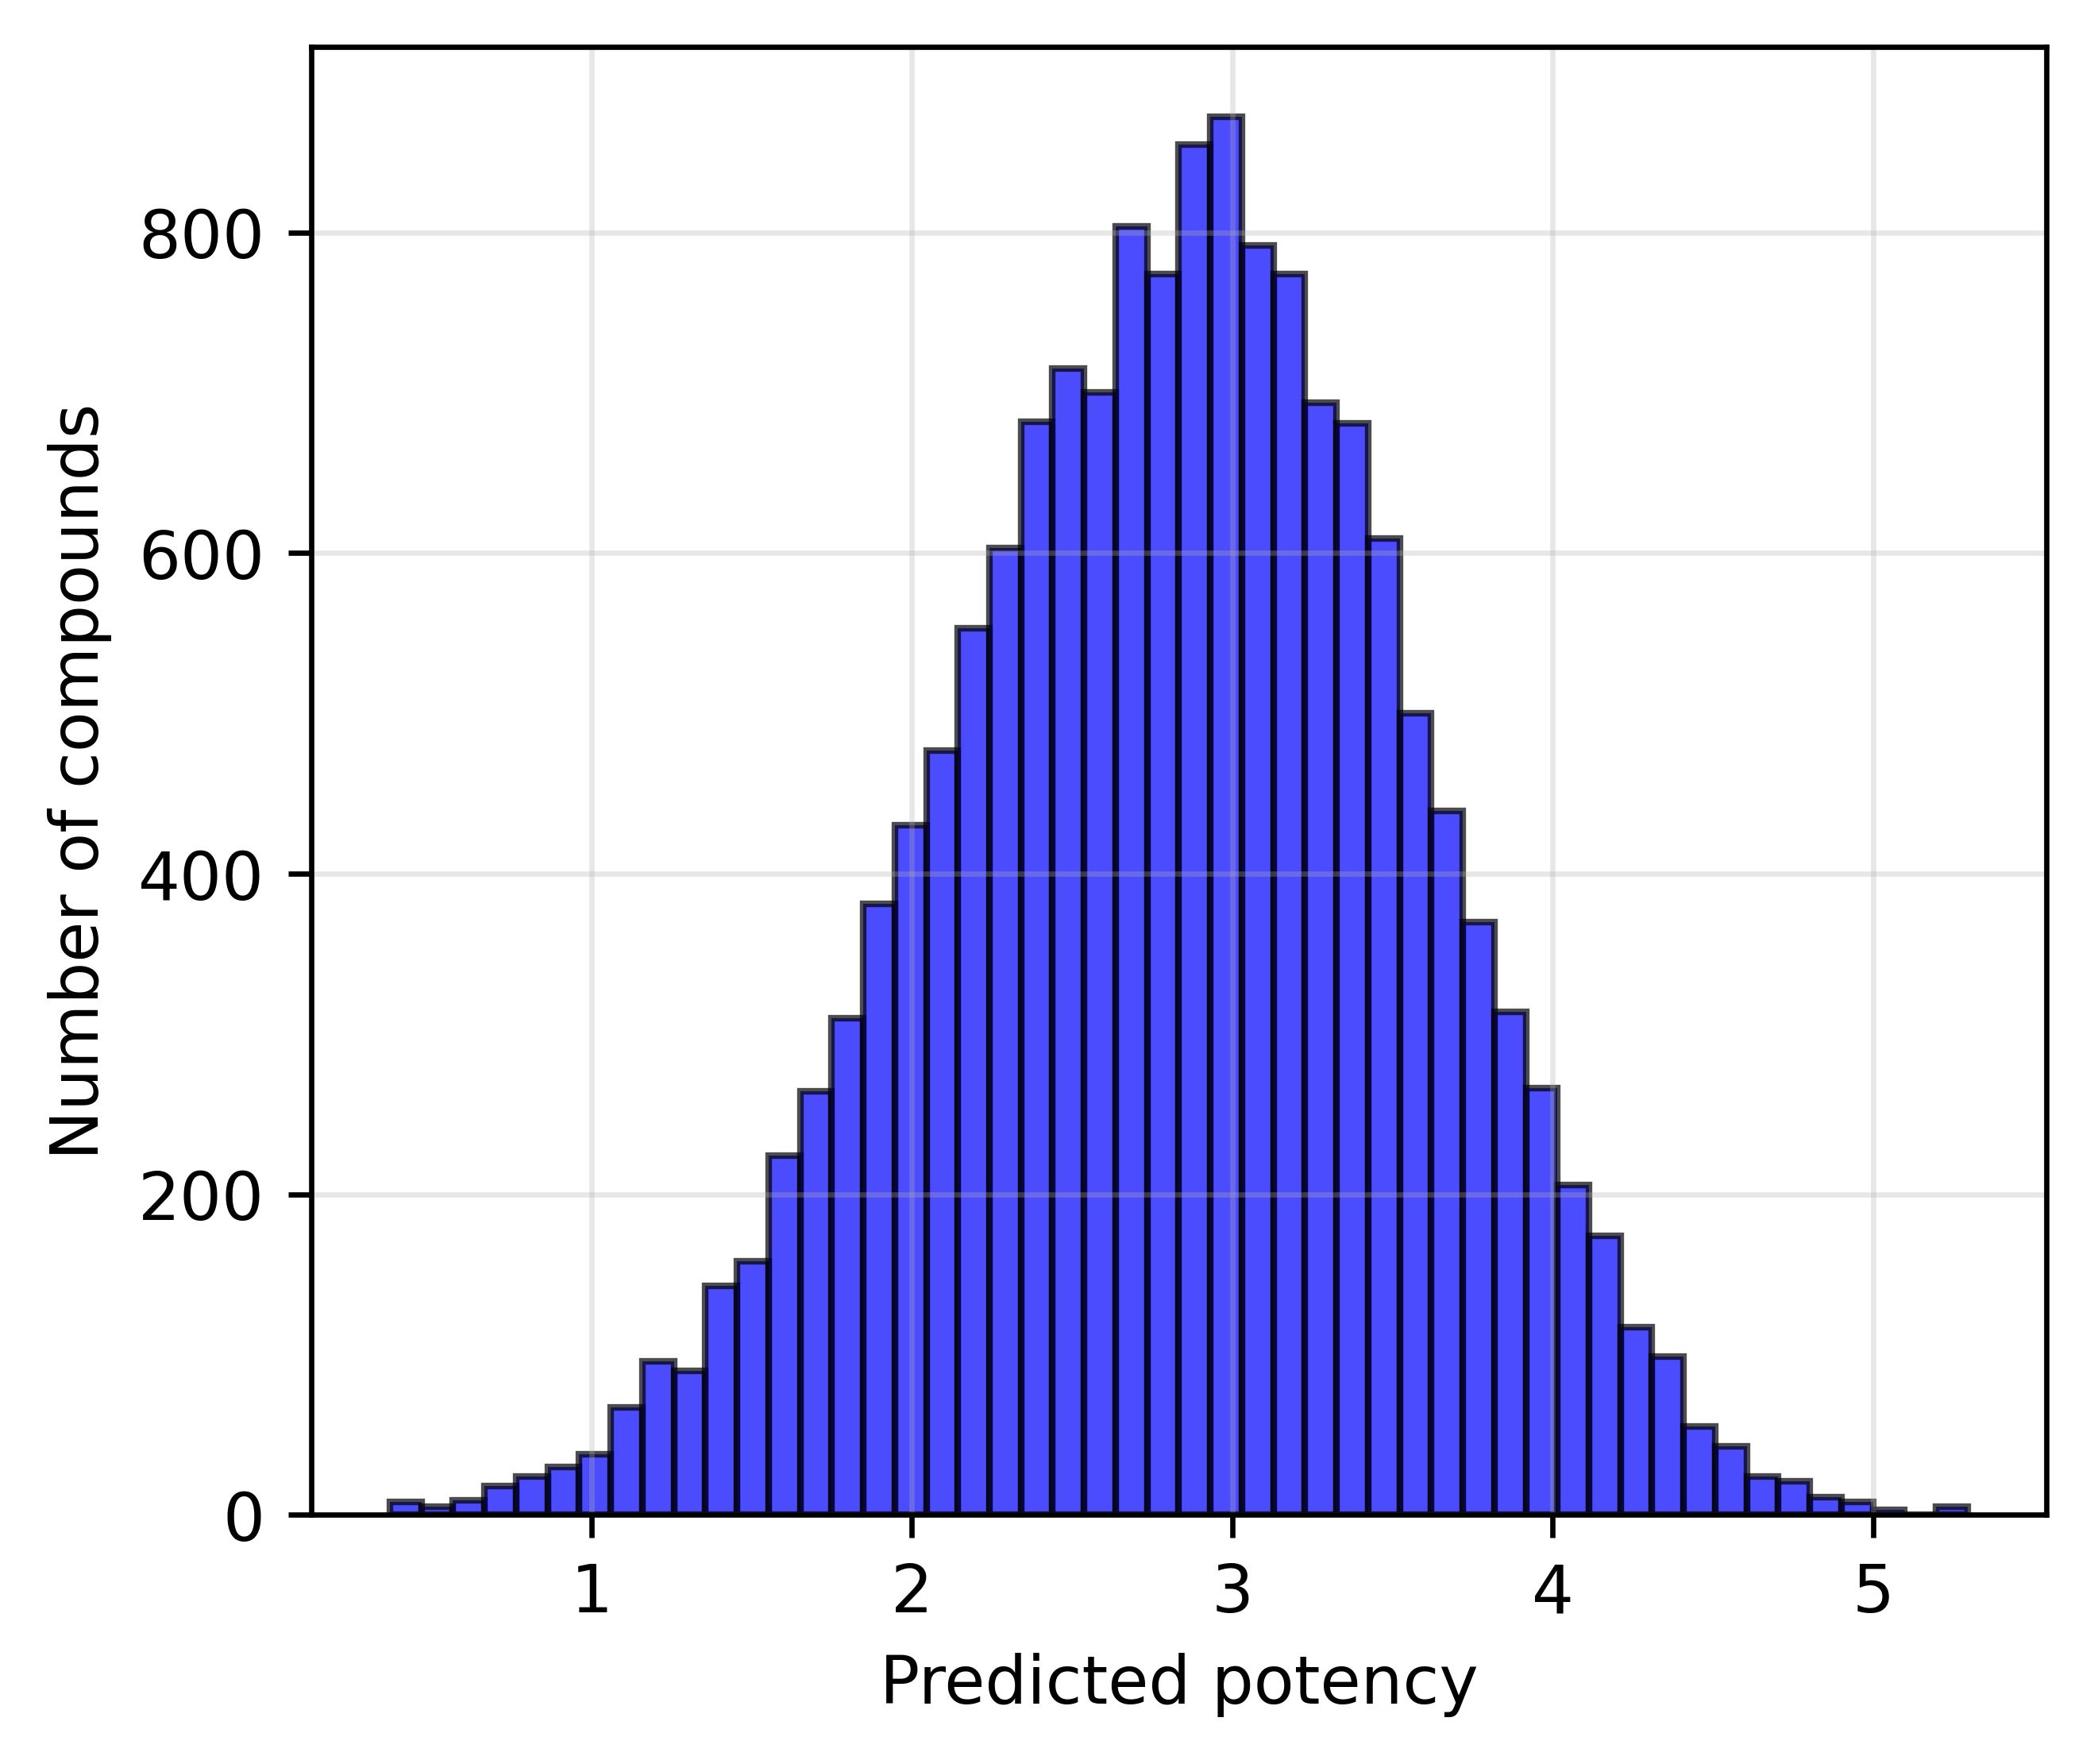

In [96]:
plt.figure(figsize=(4.7, 4.0), dpi=300)
plt.hist(Y1_lib_pred, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.xlabel("Predicted potency")
plt.ylabel("Number of compounds")
#plt.title(f"Virtual screening of custom library ({len(smi_lib)} molecules)", pad=35)
#plt.axvline(x=5, color='r', linestyle='--', linewidth=2) # label='pPotency = 5.0 (minimum)'
#plt.axvline(x=6, color='g', linestyle='--', linewidth=2) # label='pPotency = 6.0 (good)'
#plt.axvline(x=7, color='b', linestyle='--', linewidth=2) # label='pPotency = 7.0 (excellent)'

# Legend on top, outside plot area
#plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.13), ncol=3, frameon=False)

plt.grid(True, alpha=0.3)
plt.savefig(resultsDir + 'StaphylococcusBacteria/StaphylococcusBacteria_validationLCDatasets.svg', bbox_inches='tight', dpi=300)
plt.savefig(resultsDir + 'StaphylococcusBacteria/StaphylococcusBacteria_validationLCDatasets.png', bbox_inches='tight', dpi=300)
plt.show()

Let us have a look at the compounds:

In [97]:
# Define multiple priority levels
high_priority_idx = np.where(Y1_lib_pred >= 7)[0]
medium_priority_idx = np.where((Y1_lib_pred >= 6.0) & (Y1_lib_pred < 7.0))[0]
low_priority_idx = np.where((Y1_lib_pred >= 5.0) & (Y1_lib_pred < 6))[0]

print(f"High priority (pPotency ≥ 7.0): {len(high_priority_idx)} compounds")
print(f"Medium priority (6 ≤ pPotency < 7.0): {len(medium_priority_idx)} compounds")
print(f"Low priority (5 ≤ pPotency < 6): {len(low_priority_idx)} compounds")

# Use the one you need
idx = high_priority_idx  # or combine them

High priority (pPotency ≥ 7.0): 0 compounds
Medium priority (6 ≤ pPotency < 7.0): 0 compounds
Low priority (5 ≤ pPotency < 6): 8 compounds


In [98]:
LCAntibacterialsData_final = LCAntibacterialsData.iloc[idx].copy()
LCAntibacterialsData_final['pPotency_prediction'] = Y1_lib_pred[idx]
LCAntibacterialsData_final = LCAntibacterialsData_final.filter(
    items=["SMILES", "pPotency_prediction", "clogP"]
)
LCAntibacterialsData_final

,SMILES,pPotency_prediction,clogP


In [ ]:
molecules = [Chem.MolFromSmiles(smi) for smi in LCAntibacterialsData_final.SMILES[:50]]

Draw.MolsToGridImage(molecules, subImgSize=(200,200), molsPerRow=3, useSVG=True)

### Top 20 compounds with higher pPPotency

In [100]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Get the cutoff pPotency (minimum value in top 20)
cutoff_pPotency = Y1_lib_pred[top_20_idx[-1]]  # Last (20th) value

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f}")
print(f"Highest predicted pPotency: {Y1_lib_pred[top_20_idx[0]]:.2f}")
print(f"Range of top 20: {cutoff_pPotency:.2f} - {Y1_lib_pred[top_20_idx[0]]:.2f}")

Top 20 compounds cutoff pPotency: 4.88
Highest predicted pPotency: 5.29
Range of top 20: 4.88 - 5.29


In [101]:
# Get top 20 indices by highest predicted pPotency
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Create dataframe with top 20
LCAntibacterialsData_top20 = LCAntibacterialsData.iloc[top_20_idx].copy()

# Add pPotency_prediction rounded to 3 decimal places
LCAntibacterialsData_top20['pPotency_prediction'] = Y1_lib_pred[top_20_idx].round(3)

# Add IC50 column (convert pPotency to Molar units)
# IC50 (M) = 10^(-pPotency)
LCAntibacterialsData_top20['IC50 (M)'] = 10**(-Y1_lib_pred[top_20_idx])

# Add rank column at the beginning
LCAntibacterialsData_top20.insert(0, 'Rank', range(1, 21))

# Calculate ranges
pPotency_max = Y1_lib_pred[top_20_idx[0]]   # Highest (best)
pPotency_min = Y1_lib_pred[top_20_idx[-1]]  # Lowest (cutoff)
IC50_min = 10**(-pPotency_max)              # Lowest IC50 (most potent)
IC50_max = 10**(-pPotency_min)              # Highest IC50 (least potent in top 20)
IC50_min_nM = IC50_min * 1e9
IC50_max_nM = IC50_max * 1e9

# Display information
print("-"*50)
print("Top 20 Compounds with Highest Predicted pPotency")
print("-"*50)
print("\nCutoff Values (20th ranked compound):")
print(f"  pPotency:    {pPotency_min:.3f}")
print(f"  IC50:        {IC50_max:.3e} M  ({IC50_max_nM:.2f} nM)")

print("\nBest Values (1st ranked compound):")
print(f"  pPotency:    {pPotency_max:.3f}")
print(f"  IC50:        {IC50_min:.3e} M  ({IC50_min_nM:.2f} nM)")


print("Range for Top 20 Compounds:")
print(f"pPotency Range:  {pPotency_min:.3f} - {pPotency_max:.3f}")
print(f"\nIC50 Range (M):  {IC50_max:.3e} - {IC50_min:.3e}")
#print(f"IC50 Range (nM): {IC50_max_nM:.2f} - {IC50_min_nM:.2f} nM")
#print(f"                 (Δ = {pPotency_max - pPotency_min:.3f})")
#print(f"                 (Fold change = {IC50_max/IC50_min:.1f}x)")


# Set pandas display options for scientific notation
pd.options.display.float_format = lambda x: f'{x:.3e}' if abs(x) < 0.01 or abs(x) > 1000 else f'{x:.3f}'

# Display the dataframe
LCAntibacterialsData_top20 = LCAntibacterialsData_top20.filter(
    items=["Rank", "SMILES", "pPotency_prediction", "IC50 (M)"]
)
LCAntibacterialsData_top20

--------------------------------------------------
Top 20 Compounds with Highest Predicted pPotency
--------------------------------------------------

Cutoff Values (20th ranked compound):
  pPotency:    4.878
  IC50:        1.323e-05 M  (13233.64 nM)

Best Values (1st ranked compound):
  pPotency:    5.295
  IC50:        5.074e-06 M  (5074.16 nM)
Range for Top 20 Compounds:
pPotency Range:  4.878 - 5.295

IC50 Range (M):  1.323e-05 - 5.074e-06


,Rank,SMILES,pPotency_prediction,IC50 (M)
3219,1,O=C(O)CCCC(=O)c1ccccc1,5.295,5.074e-06
7178,2,O=C(Cc1ccccc1)c1ccc(O)cc1O,5.279,5.262e-06
11751,3,CCCCc1ccc(NC(=O)c2ccccc2)cc1,5.258,5.523e-06
4362,4,O=C(CCc1ccccc1)N1CCc2ccccc21,5.225,5.954e-06
7939,5,Oc1ccc(C2(c3ccccc3)CCCCC2)cc1,5.215,6.095e-06
821,6,O=C(Cc1cccnc1)N1CCc2ccccc21,5.077,8.382e-06
3975,7,O=S(=O)(NCCC1=CCCCC1)c1ccc(Br)cc1,5.067,8.563e-06
4549,8,O=C(O)c1ccc(OCCOc2ccccc2)cc1,5.064,8.621e-06
1942,9,CCCCCCc1ccc(O)cc1O,4.985,1.035e-05
3490,10,CCCCOc1ccc(C(=O)O)cc1,4.962,1.090e-05


 Saved PNG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/StaphylococcusBacteria/StaphylococcusBacteria_predictedCompounds_LCDataset.png
 Saved SVG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/StaphylococcusBacteria/StaphylococcusBacteria_predictedCompounds_LCDataset.svg


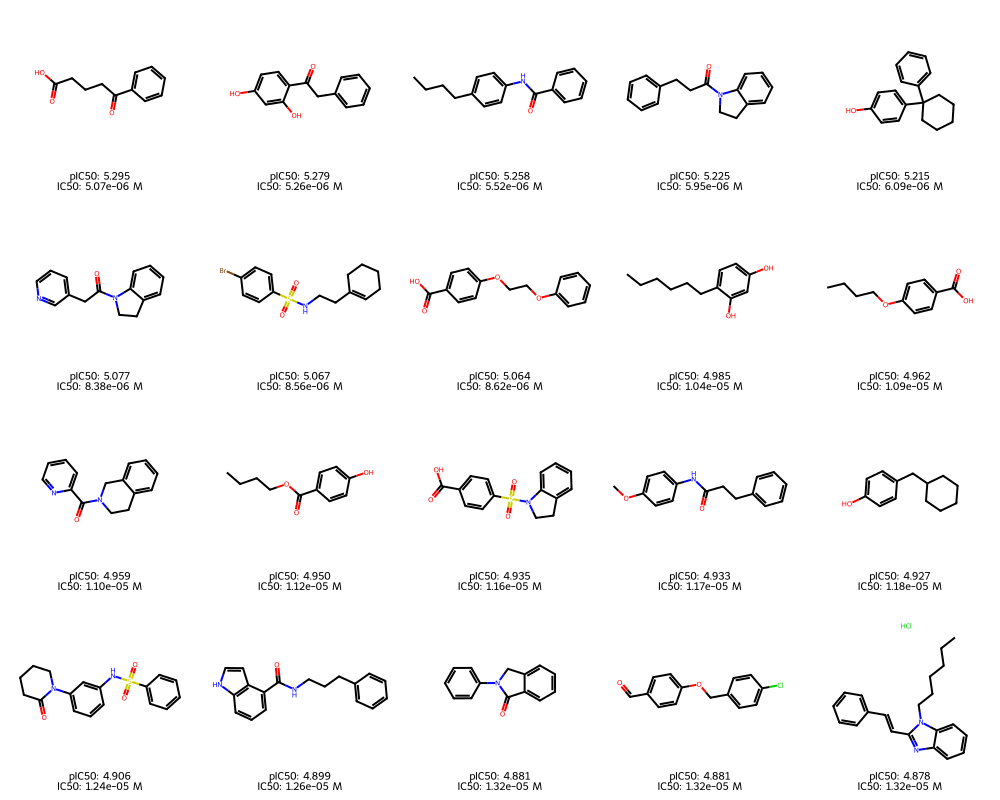

In [104]:
from rdkit import Chem
from rdkit.Chem import Draw
import os
from PIL import Image

# Setup paths
output_dir = resultsDir + 'StaphylococcusBacteria/'
os.makedirs(output_dir, exist_ok=True)

# Get molecules
molecules = [Chem.MolFromSmiles(smi) for smi in LCAntibacterialsData_top20.SMILES[:50]]

# Create legends
legends = []
for idx, row in LCAntibacterialsData_top20[:50].iterrows():
    legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (M)']:.2e} M"
    legends.append(legend)

# Generate PNG image
img = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=False, 
    legends=legends,
    returnPNG=False  # Returns PIL Image object
)

# Save PNG
output_png = output_dir + 'StaphylococcusBacteria_predictedCompounds_LCDataset.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

# Generate and save SVG
svg = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=True,
    legends=legends
)

output_svg = output_dir + 'StaphylococcusBacteria_predictedCompounds_LCDataset.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")


display(img) 